# LPHY1365: Météorologie

# Chapitre 6: Rappels et notions complémentaires de mécanique


Source: *Triplet, J.-P., & Roche, G.* (1996). Météorologie générale. Service central de la communication et de la commercialisation de Météo-France.


Le point de départ de cette première session est une image représentant la péninsule ibérique le 17 septembre 2024, alors que le centre du Portugal est soumis à des feux de forêt d'une ampleur considérable.


Mais cette photo est-elle bien réelle? Alors que les intelligences artificielles génératives inondent le web de contenu créé de toutes pièces, pourquoi cette image ne serait-elle pas, elle aussi, une construction virtuelle? 

*Questions pour les étudiant.e.s:*
- Quels sont les indices qui permettraient de vérifier l'authenticité de l'image ou de démontrer son inauthenticité?
- D'où provient l'image? 
- La source est-elle fiable?
- Les trajectoires suivies par la fumée de combustion sont-elles alignées aux vents du jour?

*Ressources disponibles:*

https://earth.nullschool.net/

https://www.windy.com/?50.842,4.438,5

https://www.tropicaltidbits.com/

https://www.wetterzentrale.de/

https://charts.ecmwf.int/




<!--Chargement de l'image satellite montrant les feux au Portugal le 17 septembre 2024-->


![image](telechargement.jpeg)

Source: https://atmosphere.copernicus.eu/wildfires-rage-across-northern-portugal-cams-tracks-their-impacts (consultée la dernière fois le 11 février 2026)

In [1]:
# Chargement du fichier netcdf portant le doux nom de "917b904f234593921f174fa06a177d56.nc" qui a été téléchargé depuis
# le site de la réanalyse ERA5. Importation des bibliothèques nécessaires pour manipuler les données et les visualiser.
# Ensuite, plot du champ de vent à 10 mètres d'altitude pour 12.00UTC au 17 septembre 2024.

import xarray as xr
import matplotlib.pyplot as plt
import requests


# Charger le fichier netcdf
try: # On essaie localement. Si le fichier pas là, on le télécharge 
  ds = xr.open_dataset("./data/91e319d26f6f4705ff1f278b3925c0b6.nc")
except FileNotFoundError:
  # Télécharger le fichier
  url = "https://raw.githubusercontent.com/fmassonn/teaching/master/LPHY1365/data/91e319d26f6f4705ff1f278b3925c0b6.nc"

  r = requests.get(url)
  with open("91e319d26f6f4705ff1f278b3925c0b6.nc", "wb") as f:
    f.write(r.content)
  ds = xr.open_dataset("./91e319d26f6f4705ff1f278b3925c0b6.nc")




# Afficher les variables disponibles pour vérifier que nous avons les données de vent à 10 mètres
print(ds)

# Prendre le temps d'examiner le nom des variables, dont la variables temporelle, pour s'assurer que nous sélectionnons les bonnes données. 
# Imprimer les dimensions du dataset pour comprendre la structure des données et identifier les variables de vent à 10 mètres.
print(ds.dims)


<xarray.Dataset>
Dimensions:    (time: 24, longitude: 121, latitude: 161)
Coordinates:
  * time       (time) datetime64[ns] 2024-09-17 ... 2024-09-17T23:00:00
  * longitude  (longitude) float32 -30.0 -29.75 -29.5 -29.25 ... -0.5 -0.25 0.0
  * latitude   (latitude) float32 60.0 59.75 59.5 59.25 ... 20.5 20.25 20.0
Data variables:
    u10        (time, latitude, longitude) float32 ...
    v10        (time, latitude, longitude) float32 ...
    t2m        (time, latitude, longitude) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.5.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 19 21:40:40 2026: cdo sellonlatbox,330,360,20,60 91...
    CDO:          Climate Data Operators version 2.5.1 (https://mpimet.mpg.de...
Frozen({'time': 24, 'longitude': 121, 'latitude': 161})


In [2]:
# La dimension "temps" s'appelle donc "time". Nous allons sélectionner les données de vent à 10 mètres d'altitude pour le 17 septembre 2024 à 12.00UTC.
# Sélectionner les données de vent à 10 mètres d'altitude pour le 17 septembre 2024 à 12.00UTC

# Convertir la date et l'heure en format compatible avec xarray
time_selection = '2024-09-17T12:00:00'
# Sélectionner les données de vent à 10 mètres d'altitude pour le temps spécifié
u10 = ds['u10'].sel(time=time_selection)
v10 = ds['v10'].sel(time=time_selection)
# Afficher les données sélectionnées pour vérifier qu'elles sont correctes
print(u10)
print(v10)


<xarray.DataArray 'u10' (latitude: 161, longitude: 121)>
[19481 values with dtype=float32]
Coordinates:
    time       datetime64[ns] 2024-09-17T12:00:00
  * longitude  (longitude) float32 -30.0 -29.75 -29.5 -29.25 ... -0.5 -0.25 0.0
  * latitude   (latitude) float32 60.0 59.75 59.5 59.25 ... 20.5 20.25 20.0
Attributes:
    long_name:  10 metre U wind component
    units:      m s**-1
<xarray.DataArray 'v10' (latitude: 161, longitude: 121)>
[19481 values with dtype=float32]
Coordinates:
    time       datetime64[ns] 2024-09-17T12:00:00
  * longitude  (longitude) float32 -30.0 -29.75 -29.5 -29.25 ... -0.5 -0.25 0.0
  * latitude   (latitude) float32 60.0 59.75 59.5 59.25 ... 20.5 20.25 20.0
Attributes:
    long_name:  10 metre V wind component
    units:      m s**-1


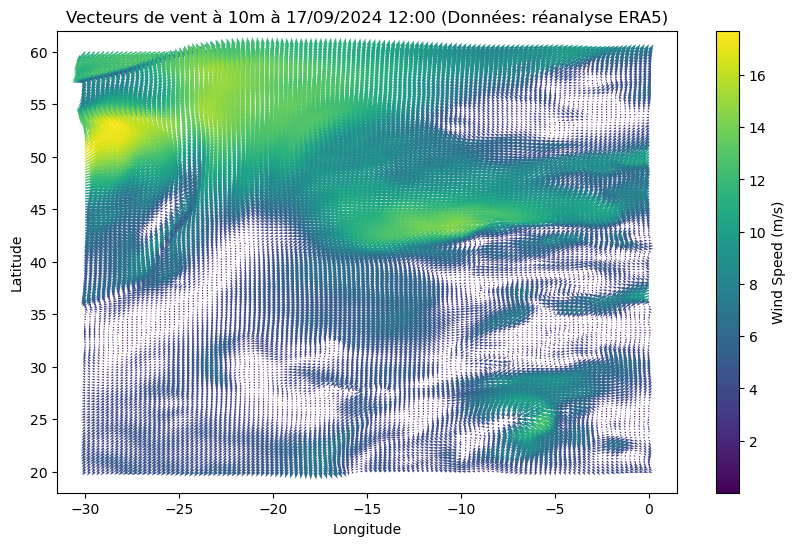

In [3]:
# Plot du champ de vent à 10 mètres par des flèches (quiver plot) pour visualiser la direction du vent.
# Nous choisissons en plus de créer un champ scalaire "wind speed" qui est la norme du vent. Les flèches
# auront une longueur identique et le fond de carte sera coloré en fonction de la vitesse du vent.
import numpy as np
import pandas as pd
# Calculer la vitesse du vent à partir des composantes u et v
wind_speed = np.sqrt(u10**2 + v10**2)
# Créer une grille de coordonnées pour le plot
lon = ds['longitude']
lat = ds['latitude']
# Créer un quiver plot pour les composantes du vent
plt.figure(figsize=(10, 6))
plt.quiver(lon, lat, u10, v10, wind_speed, scale=500, cmap='viridis')
plt.colorbar(label='Wind Speed (m/s)')

# On affiche le time_selection en format DD/MM/YYYY HH:MM pour le titre du graphique
time_selection_readable = pd.to_datetime(time_selection).strftime('%d/%m/%Y %H:%M')

plt.title('Vecteurs de vent à 10m à ' + time_selection_readable + ' (Données: réanalyse ERA5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

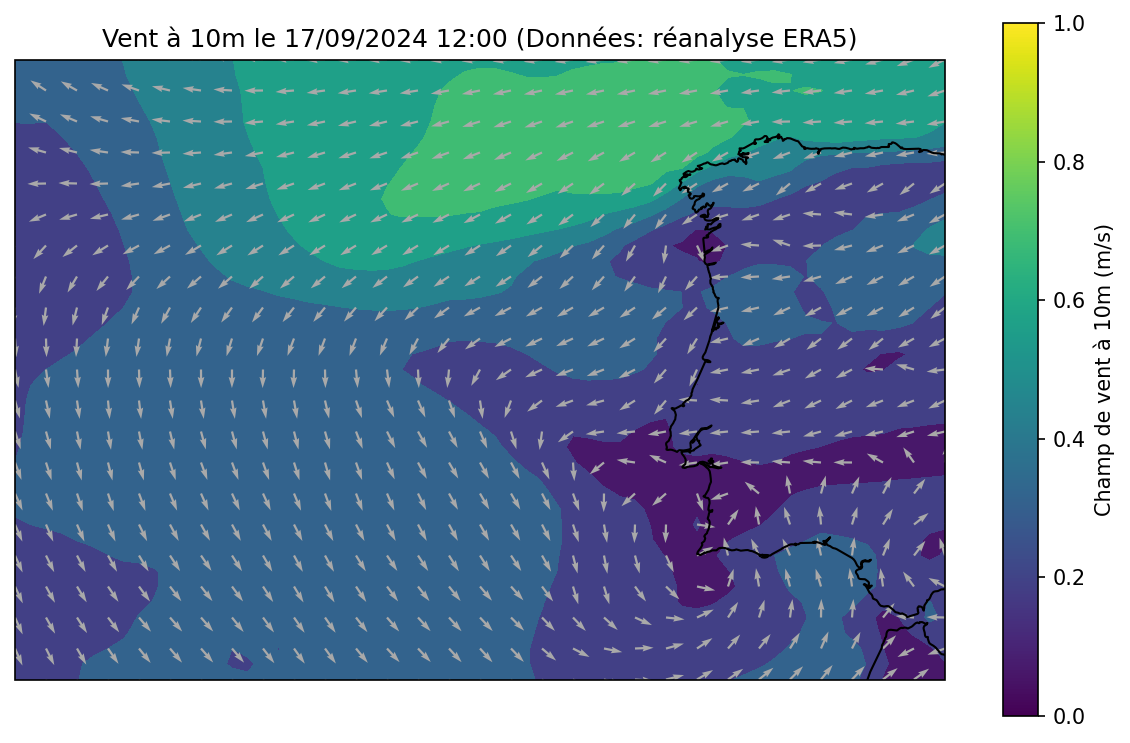

In [4]:
# Tout ça a une bonne tête. Faison maintenant un "zoom" sur le Portugal, qui est la zone qui nous intéresse.
# Définir les limites de la zone d'intérêt (Portugal)
lon_min, lon_max = -20, -5
lat_min, lat_max = 35, 45

# Créer un jeu de données "zoomé" pour la zone d'intérêt
u10_zoom = u10.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
v10_zoom = v10.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
wind_speed_zoom = wind_speed.sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_min, lat_max))
lon_zoom = lon.sel(longitude=slice(lon_min, lon_max))
lat_zoom = lat.sel(latitude=slice(lat_min, lat_max))

# Créer un quiver plot pour la zone d'intérêt. Nous utilisont maintenant Cartopy pour ajouter une carte de fond.
# Importation de la lbriéthèque Cartopy pour la visualisation cartographique
plt.figure(figsize=(10, 6), dpi = 150)

# installer cartopy si nécessaire
try:
  import cartopy.crs as ccrs
except ModuleNotFoundError:
  !pip install cartopy
  import cartopy.crs as ccrs

# Création du fond de carte avec Cartopy
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
# Ajouter les flèches de vent
plt.contourf(lon, lat, wind_speed, cmap='viridis')
# normalize to get equal length arrows. plot arrows in dark grey and plot only every second arrow to avoid overcrowding
declutter = 2
plt.quiver(lon[ ::declutter], lat[::declutter], u10[::declutter, ::declutter] / wind_speed[::declutter, ::declutter], v10[::declutter, ::declutter] / wind_speed[::declutter, ::declutter], scale=50, color='darkgrey')
plt.colorbar(label='Champ de vent à 10m (m/s)')
plt.title('Vent à 10m le ' + time_selection_readable + ' (Données: réanalyse ERA5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


## 6.1 - Quelques éléments de cinématique


Considérons une particule **ponctuelle** et intéressons-nous à son mouvement, décrit par une courbe $C$.

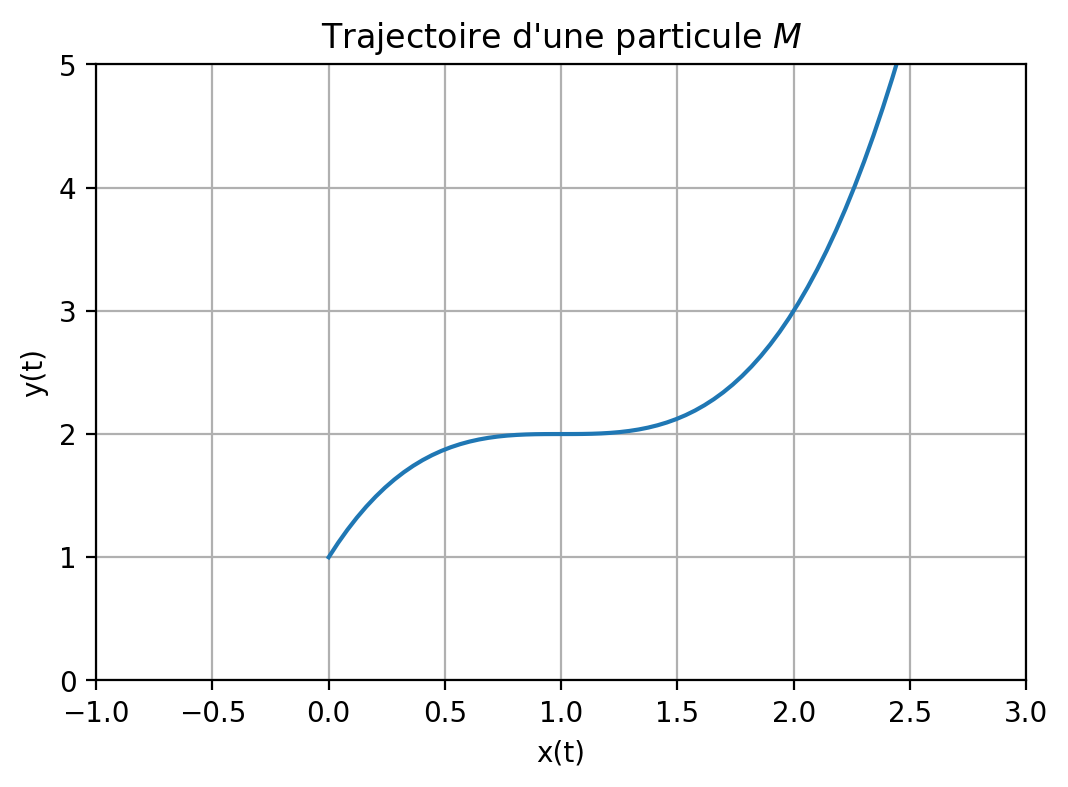

In [5]:
# Création d'un graphe bi-dimensionnel (axes x et y) décrivant la trajectoire d'une particule M (choisie ici comme une courbe paramétrée par le temps x(t) = t et y(t) = (t-1)^2 + 1
# Reset des variables
%reset -f

import numpy as np
import matplotlib.pyplot as plt



# Définir la fonction de la trajectoire
def trajectory(t):
    x = t
    y = (t - 1)**3 +2
    return x, y
# Générer des points de temps pour tracer la trajectoire
t_values = np.linspace(0, 4, 100)
x_values, y_values = trajectory(t_values)


# Tracer la trajectoire
plt.figure(figsize=(6, 4), dpi = 200)
plt.plot(x_values, y_values, label='Trajectoire de M')
plt.title('Trajectoire d\'une particule $M$')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.xlim(-1, 3)
plt.ylim(0, 5)  
plt.grid()
plt.show()





En tant qu'objet géométrique, cette trajectoire nous renseigne certes sur l'ensemble des points de l'espace qui ont été occupés par la particule lors de son mouvement, MAIS ne nous enseigne rien sur la façon dont elle l'a parcourue! C'est pourquoi la trajectoire est mathématiquement exprimée de façon paramétrique par une variable indépendante - le temps - qui va relier entre elles les variables spatiales $x$ et $y$.

#### 6.1.1 - Le vecteur position

Le vecteur position $\vec{r}(t)$ relie une origine $0$ préalablement fixée (par exemple, le point $(0, 0)$) et le point correspondant à la position de la particule au temps $t$:

$$\vec{r}(t) := \overrightarrow{OM} $$

Ce vecteur, bien qu'essentiel pour définir les vecteurs vitesse et accélération, est en pratique rarement utilisé en physique des fluides géophysiques car l'état dynamique de l'atmosphère peut se décrire par le champ de vitesse seul, et/ou par des fonctions de celui-ci.

#### 6.1.2 - Le vecteur vitesse
On appelle $M_0$ le point de la trajectoire correspondant au temps initial $t=0$. 

Le vecteur *vitesse moyenne* entre deux instants successifs est défini comme étant la différence entre le vecteur position à deux instants successifs $t$ et $t+\Delta t$ (correspondant à deux points $M$ et $M_1$), et divisé par l'intervalle de temps qui s'est écoulé entre ces deux instants. Puisque le vecteur position est toujours défini depuis une origine commune $O$, il est facile de montrer que le vecteur vitesse moyenne est colinéaire au segment reliant M et M_1

$$ \overrightarrow{v}_m(t) = \frac{\overrightarrow{MM}_1}{\Delta t} $$

On définit le vecteur *vitesse de la particule à l'instant $t$* comme la limite du vecteur vitesse moyenne lorsque celle-ci est prise sur un intervalle qui tend vers 0:

$$\overrightarrow{v}(t) = \lim_{\Delta t \to 0} \frac{\overrightarrow{MM}_1}{\Delta t}$$


Le vecteur vitesse est donc toujours tangent à la trajectoire au point $M$, de même sens que le vecteur vitesse moyenne, et de module égal à

$$v(t) := \| \overrightarrow{v}(t)  \| = \lim_{\Delta t \to 0} \frac{\|\overrightarrow{MM}_1\|}{\Delta t}$$

In [ ]:
# Ajout sur le graphe du point M0 correspondant à t=0, et ajouter sur le graphe un point arbitraire (x,y)
# (choisi ici comme correspondant à t = 1)

t0 = 0
M0 = trajectory(t0)
tt = 1.5 # pour désigner la variable courante t
ttpD = 3.5 # Pour tt + delta t
M = trajectory(tt)
# Créer une animation avec interaction pour faire varier dt et voir le point M1 se déplacer le long de la trajectoire
from ipywidgets import interact
import ipywidgets as widgets


def update(dt):
    t1 = tt + dt
    M1 = trajectory(t1)
    plt.figure(figsize=(6, 4), dpi = 200)
    plt.plot(x_values, y_values, label='Trajectoire de M')
    plt.scatter(*M0, 100, color='red',  label=f'M0 (t=0)')
    plt.scatter(*M, 100, color='blue',  label=f'M (t={tt})', zorder = 5)
    plt.scatter(*M1, 100,  color='green', label=f'M1 (t={t1:.2f})', zorder=5)

    # Définir le vecteur vitesse moyenne entre M et M1.
    v_moy = [(M1[0] - M[0]) / dt, (M1[1] - M[1]) / dt]
    # Tracer en pointillés la ligne reliant M et le point M1 (en l'étendant bien au-delà) pour visualiser la direction de la trajectoire entre ces deux points.
    # definition d'un point Mx posé proportionnellement bien plus loin que M1
    Mx = [M[0] + 1e9 * (M1[0] - M[0]), M[1] + 1e9 * (M1[1] - M[1])]


    plt.plot([M[0], Mx[0]], [M[1], Mx[1]], 'k--', label='Direction de la trajectoire')
    # Restreindre les axes pour mieux visualiser la trajectoire et les points M, M1 et M0
    plt.xlim(-1, 3)
    plt.ylim(0, 6)  

    #  Faire une flèche épaisse et colorée en orange pour la différencier des autres éléments du graphe. Ajouter une légende pour expliquer ce que représente cette flèche.
    # Faire en sorte que la tête de flèche soit perpendiculaire à la trajectoire en M1 pour mieux visualiser la direction de la vitesse moyenne.
    plt.arrow(M[0], M[1], v_moy[0], v_moy[1],  head_length=0.2, head_width=0.1, linewidth=4, alpha = 0.8, fc='orange', ec='orange', label='Vitesse moyenne M -> M1', zorder = 10)
    
    plt.title('Trajectoire d\'une particule $M$')
    plt.gca().set_axisbelow(True)
    plt.xlabel('x(t)')
    plt.ylabel('y(t)')
    plt.grid()
    plt.legend()
    plt.show()


# Slider
interact(update, dt=(0.001, 2, 0.001))



interactive(children=(FloatSlider(value=1.0, description='dt', max=2.0, min=0.001, step=0.001), Output()), _do…

<function __main__.update(dt)>

Le module (ou norme) du vecteur vitesse peut aussi se calculer, de façon équivalente, via **l'abscisse curviligne $s$** de la trajectoire décrite par notre particule. Cette abscisse curviligne est un scalaire dépendant uniquement du temps et décrivant la distance parcourue, au temps $t$, par la particule puis l'origine jusqu'au point actuel. Il s'agit donc également de la longueur de l'arc décrit par la courbe $C$ entre le point $M_0$ et le pont $M$. La norme du vecteur vitesse peut ainsi s'exprimer comme

$$V(t) = \lim_{\Delta t \to 0} \frac{s(t+\Delta t) - s(t)}{\Delta t}$$

Enfin, si $\vec{T}$ désigne un vecteur unitaire ($\|\vec{T}\| = 1$) tangent à la courbe $C$ au point $M$, alors on peut exprimer le vecteur vitesse comme 

$$\overrightarrow{v}(t) = V(t) \vec{T} $$

#### 6.1.3 - Le vecteur accélération

Le **vecteur accélération** est, par définition, la dérivée du vecteur vitesse. On démontre en classe que ce vecteur accélération se décompose en deux contributions:

- une contribution tangentielle au mouvement
- une contribution normale au mouvement

$$\overrightarrow{a} = \vec{a}_T + \vec{a}_N = \frac{\textrm{d}^2 s}{\textrm{d}t^2} \vec{T} + \frac{V^2}{R} \vec{N} $$

où $R$ est le *rayon de courbure* de la courbe $C$ au point $M$ et $\vec{N}$ est le vecteur unitaire normal à $C$ au point $M$ (par convention, $\vec{n}$ pointe toujours vers l'intérieur)


Visualisons maintenant ce vecteur $\vec{a}$ ainsi que ses deux contributions $\vec{a}_T$ et $\vec{a}_N$ pour le mouvement étudié plus haut:


In [ ]:
# Calcul analytique du vecteur vitesse ainsi que du vecteur accélération à partir de la fonction de la trajectoire.
# Par hypothèse le champ de vitesse est donné par la fonction paramétrique u(t) = 1 et v(t) = 3(t-1)^2. Le champ d'accélération est donc donné par ax = 0 et ay = 6(t-1).

# Figure représentant la trajectoire de la particule M.
# Calcul de la vitesse à partir des composantes u et v

# On peut questionner les étudiants en demandant où la vitesse est la plus éleée, le rayon de courbure, l'accélération, etc.

# On insère par ailleurs ce graphe dans une fonction update afin de pouvoir faire varier le temps t et voir la particule se déplacer le long de la trajectoire, avec une couleur qui change en fonction de sa vitesse.

def update(t):
    x, y = trajectory(t)
    u = 1
    v = 3 * (t - 1)**2
    speed = np.sqrt(u**2 + v**2)
    
    plt.figure(figsize=(6, 4), dpi = 200)
    plt.plot(x_values, y_values, label='Trajectoire de M')
    plt.scatter(x, y, color=plt.cm.viridis(speed / np.max(speed)), s=100, label=f'M (t={t:.2f})', zorder = 10)
    # Flèche partant du point M et représentant le vecteur vitesse à ce point.
    plt.arrow(x, y, u, v, head_length=0.2, head_width=0.1, linewidth=2, alpha = 0.8, fc='orange', ec='orange', label='Vitesse instantanée', zorder = 10)

    # Flèche représentant le vecteur accélération à ce point. La flèche d'accélération est colorée en rouge et plus épaisse que celle de la vitesse pour la différencier visuellement.
    ax = 0
    ay = 6 * (t - 1)
    plt.arrow(x, y, ax, ay, head_length=0.2, head_width=0.1, linewidth=3, alpha = 0.8, fc='red', ec='red', label='Accélération instantanée', zorder = 10)

    # Calcul du rayon de courbure. On démontre (cf. cours de maths) que ce rayon de courbure est donné par R = (1+ f'(x)^2)^3/2 / |f''(x)|. On peut calculer f'(x) et f''(x) à partir de la fonction de la trajectoire.
    f_prime = 3 * (t - 1)**2
    f_double_prime = 6 * (t - 1)
    R = (1 + f_prime**2)**(3/2) / np.abs(f_double_prime)
    # Tracer un cercle de rayon R centré sur le point M pour visualiser le rayon de courbure à ce point. La couleur du cercle est choisie pour être différente de celle des flèches de vitesse et d'accélération pour la différencier visuellement.
    circle = plt.Circle((x, y), R, color='purple', fill=False, label='Rayon de courbure', zorder = 5)
    plt.gca().add_patch(circle) 

    # Définition du vecteur unitaire tangent à la trajectoire.
    T = [u / speed, v / speed]

    # Définition du vecteur unitaire normal à la trajectoire. Comme ce vecteur, en produit scalaire avec le tangente, doit être égal à zéro, on peut le définir comme suit (en tournant la tangente de 90 degrés dans le sens inverse des aiguilles d'une montre)
    # Cependant, par convention, on le définit toujours comme pointant vers l'intérieur de la courbure, c'est à dire dans le sens des aiguilles d'une montre. C'est pour cela que le vecteur normal est défini comme suit (en tournant la tangente de 90 degrés dans le sens des aiguilles d'une montre)
    # Dans ce cas particulier d'une fonction de la forme y = f(x), la direction du vecteur normal est donnée par le signe de f''(x). 
  
    N = [T[1] * (-np.sign(f_double_prime)), -T[0] * (-np.sign(f_double_prime)) ] 
    
    # Contribution normale à l'accélaration
    an = speed**2 / R
    # Vecteur normal correspondant
    an_vector = [an * N[0], an * N[1]]

    # Contribution tangentielle à l'accélaration. Calculé ici comme le vecteur accélération totale moins la contribution normale (parce que j'ai la flemme de calculer la dérivée de la vitesse pour trouver l'accélération tangentielle) :-)
    at_vector= [ax - an_vector[0], ay - an_vector[1]]
    at = np.sqrt(at_vector[0]**2 + at_vector[1]**2)
    

    # Plot des deux contributions. Ces contributions sont mises en pointillés pour les différencier de la flèche d'accélération totale. La contribution tangentielle est colorée en rouge et la contribution normale est colorée en violet pour les différencier visuellement.
    plt.arrow(x, y, at_vector[0], at_vector[1], head_length=0.2, head_width=0.1, linewidth=1, alpha = 0.8, fc='red', ec='red', label='Accélération tangentielle', zorder = 10, linestyle=':')
    plt.arrow(x, y, an_vector[0], an_vector[1], head_length=0.2, head_width=0.1, linewidth=1, alpha = 0.8, fc='purple', ec='purple', label='Accélération normale', zorder = 10, linestyle=':')
   

    plt.gca().set_aspect('equal', adjustable='datalim')
    plt.title('Visualisation des aspects de courbure et d\'accélération d\'une particule $M$')
    plt.xlabel('x(t)')
    plt.ylabel('y(t)')
    plt.xlim(-1, 5)
    plt.ylim(-1, 5)  
    plt.grid()
    plt.legend()
    plt.show()

# Slider
interact(update, t= (0, 4, 0.01))


# On vérifie que la vitesse linéaire du point est faible au voisinage du minimum car c'est là que v(t) est le plus petit.



interactive(children=(FloatSlider(value=2.0, description='t', max=4.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.update(t)>

#### 6.1.4 - Et pour plusieurs particules?

L'étude de la mécanique des fluides a pour objectif de généraliser les concepts introduits à un ensemble de particules évoluant individuellement dans leur mouvement mais répondant à des contraintes collectives et globales.

Lorsque nous souhaitons étudier le mouvement des particules d'un fluides et caractériser un écoulement, deux approches (tout aussi valables et légitimes l'une que l'autre) sont possibles:

- L'approche (ou méthode ou description) **lagrangienne** (du nom de Joseph-Louis Lagrange, mathématicien et mécanicien italien, 1736-1813) prend le parti de suivre *dans leur mouvement* ces particules sur leurs propres trajectoires, et d'étudier les propriétés de ces particules (leur vitesse, mais aussi leur altitude, température, ...) au fur et à mesure que le temps passe. Avec cette approche, nous "suivons" le fluide de l'intérieur. Cette approche est particulièrement pertinente pour relier des concepts mécaniques à des observations prises, par exemple, à bord de ballons-sondes ou de bouées dérivantes qui en première approximation suivent le fluide dans son mouvement.
- L'approche (ou méthode ou description) **eulérienne** (du nom de Leonhard Euler, mathématicien et physicien suisse, 1707-1783) prend le parti d'associer à chaque point de l'espace un champ de vitesse et d'étudier les trajectoires qui en résultent. Cette approche est particulièrement pertinente pour relier des concepts mécaniques à des observations prises à grande échelle et de façon structurée spatialement, comme des mesures satellitaires ou prises depuis des stations fixes au sol.


A titre d'exemple: un conducteur roulant à 120 km/h sur une route de pente 3% et passe sous un pont à midi. Connaissant ces informations, il peut calculer son gain en altitude après une minute en connaissant sa propre vitesse, le temps écoulé, et la pente de la route (+60 m). Par ailleurs, un observateur situé au-dessus du pont peut facilement calculer que si l'autoroute baigne dans un champ de vitesse de 120 km/h et dans un champ d'élévation d'une pente de 3% vers les x-positifs, alors toute particule (dont celle qui passe sous le pont à midi) gagnera 30 m toutes les 30 secondes, soit 60 m par minute.

Dans la suite, nous travaillerons quasi-exclusivement dans le formalisme eulérien, car il est en pratique impossible d'identifier, suivre et modéliser l'évolution de particules individuelles. Il est cependant à noter qu'il existe de nombreux exemples dans lesquels l'approche lagrangienne est plus adaptée, flexible et commode, mais aussi moins coûteuse en temps de calcul, pour résoudre certains problèmes (back-tracking atmosphérique, déformation de nuages de polluants, ...). Le formalisme eulérien permet par ailleurs la visualisation globale et à grande échelle des dynamiques atmosphériques, ce qui est un de nos objectifs.



#### 6.1.5 - Les lignes de courant

Connaissant le champ de vitesse à un instant donné $t$, on peut tracer les lignes tangentes à l'ensemble des vecteurs vitesse en tous les points du domaine, et les relier entre elles. On obtient alors des "lignes de courant".

Il convient d'être prudent par rapport à l'interprétation de ces lignes de courant, car **elles ne représentent général pas exactement les trajectoires du fluide**: les lignes de courant se déforment au cours du temps (pour des champs non-stationnaires), et de surcroît, des particules munies d'une masse seront déviées au cours de leur mouvement par la présence de forces fictives (voir Chapitre 7).



In [8]:
# Création d'une figure (1, 2) représentant un champ de vitesse et les lignes de courant correspondantes.
# On part d'une fonction de courant relativement simple, 
# phi(x,y) = cos(2 *pi * freq * t) * sin(pi*x) * sin(pi*y) qui correspond à un 
# champ de vitesse donné par u = -dphi/dy et v = dphi/dx.
#  

%reset -f
import numpy as np
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib.pyplot as plt


x = np.linspace(0, 1, 100)
y = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 1000)
freq = 2

phi = lambda x, y, t, freq: np.cos(2 * np.pi * freq * t) * np.sin(np.pi * 2.0 * x) * np.sin(np.pi * y)
u = lambda x, y, t, freq: -np.cos(2 * np.pi
    * freq * t) * np.sin(np.pi * 2.0 * x) * np.cos(np.pi * y) * np.pi 
v = lambda x, y, t, freq: np.cos(2 * np.pi * freq * t) * np.cos(np.pi * 2.0 * x) * np.sin(np.pi * y) * np.pi
# On crée une grille de points pour tracer le champ de vitesse et les lignes de courant
X, Y = np.meshgrid(x, y)

# On va créer une fonction update() et un slider pour pouvoir visualiser le champ et son évolution

declutter = 5 # pour éviter d'avoir trop de flèches sur le graphe
def update(t):
    U = u(X, Y, t, freq)
    V = v(X, Y, t, freq)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.quiver(X[::declutter, ::declutter], Y[::declutter, ::declutter], 
               U[::declutter, ::declutter], V[::declutter, ::declutter], 
               angles='xy', scale_units='xy', scale=50, width=0.002, 
               headwidth=3, headlength=5, headaxislength=4.5, minlength=0.1)
    plt.title(f'Champ de vitesse à t={t:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid()

    # Tracer les lignes de courant. Les lignes de courant sont les courbes tangentes au champ de vitesse en chaque point. On peut les tracer en utilisant la fonction streamplot de Matplotlib.
    plt.subplot(1, 2, 2)
    plt.streamplot(X, Y, U, V)
    plt.title(f'Lignes de courant à t={t:.2f}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid()
    plt.tight_layout()
    plt.show()

# Slider
interact(update, t=(0, 1, 0.01))



interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.update(t)>

## 6.2 - Examen cinématique de quelques mouvements plans élémentaires


L'exemple utilisé jusqu'ici peut être repris pour introduire le concept de **champ de vitesse**. Nous avions défini la trajectoire d'une particule au moyen d'une courbe $C$ dont les coordonnées $x$ et $y$ sont paramétrées par la variable "temps" $t$: $x=x(t)$ et $y=y(t)$.

Voici à quoi ressemble le vecteur vitesse de la courbe ci-dessus, évalué à intervalles réguliers sur l'axe $x$, le long de cette courbe.

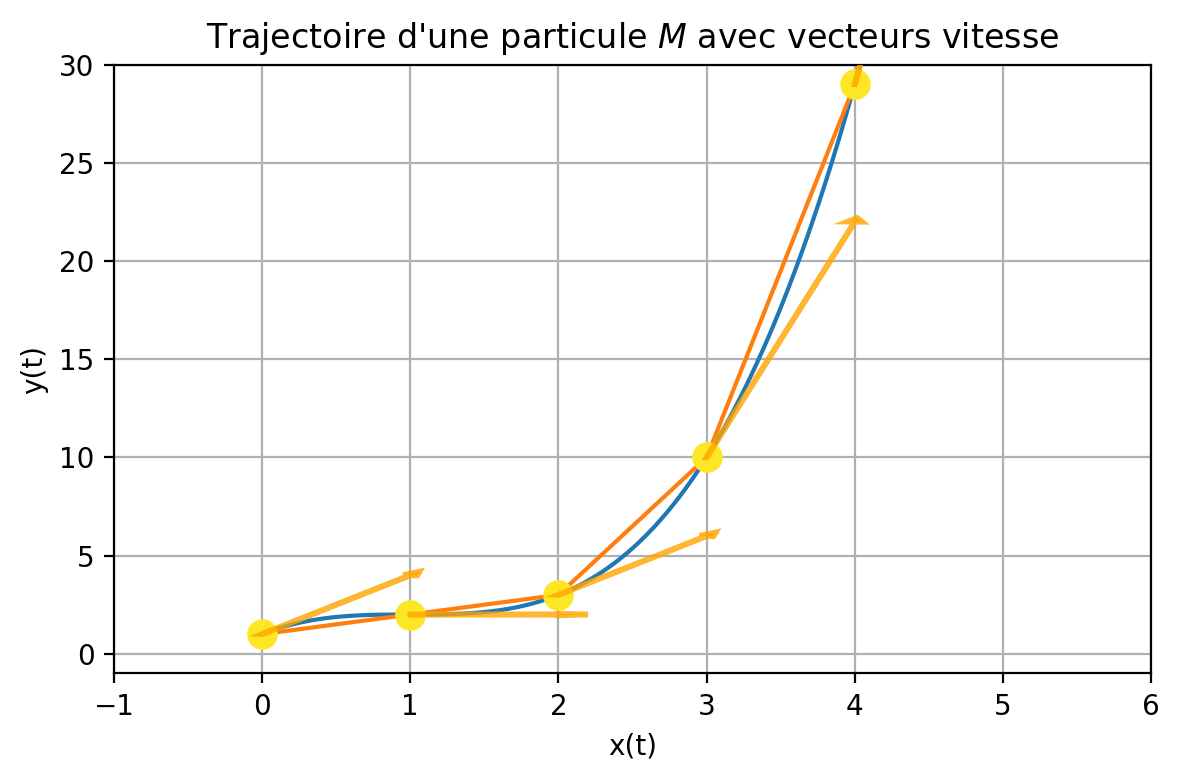

In [9]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt


# Nous représentons le vecteur vitesse de la trajectoire ci-dessus, à intervalles réguliers x= 0 jusque x = 5, par pas de 0.5.
# On repart de la fonction "trajectory" introduite ci-dessus pour calculer les points de la trajectoire correspondant à ces valeurs de x, et ensuite calculer le vecteur vitesse à ces points pour les représenter par des flèches sur le graphe.


x_curve = np.arange(0, 5.5, 0.01)
y_curve = (x_curve - 1)**3 + 2
x_values = np.arange(0, 5.5, 1)
plt.figure(figsize=(6, 4), dpi = 200)
plt.plot(x_curve, y_curve, label='Trajectoire de M')
for x in x_values:
    t = x  # Comme x(t) = t, on peut directement utiliser x comme temps
    y = (t - 1)**3 + 2  # Calcul de y à partir de la fonction de la trajectoire
    u = 1  # Composante de la vitesse en x
    v = 3 * (t - 1)**2  # Composante de la vitesse en y
    speed = np.sqrt(u**2 + v**2)  # Calcul de la vitesse totale

    # Tracer le point correspondant à ce temps sur la trajectoire, avec une couleur selon la vitesse
    plt.scatter(x, y, color=plt.cm.viridis(speed / np.max(speed)), s=100, label=f'M (t={t:.2f})', zorder = 10)

    # Tracer une flèche représentant le vecteur vitesse à ce point. La longueur de la flèche est normalisée pour être visible sur le graphe.
    plt.arrow(x, y, u , v, head_length=0.2, head_width=0.1, linewidth=2, alpha = 0.8, fc='orange', ec='orange', label='Vitesse instantanée', zorder = 10)

plt.plot(x_values, (x_values - 1)**3 + 2, label='Trajectoire de M')
plt.title('Trajectoire d\'une particule $M$ avec vecteurs vitesse')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.xlim(-1, 6)
plt.ylim(-1, 30)
plt.grid()
plt.tight_layout()
plt.show()



Nous allons maintenant remplir l'ensemble du domaine de ce types de flèches en définissant un **champ de vitesse** comme un fonction vectorielle $\vec{u}$ à deux composantes ($u$ et $v$) dépendant chacune de deux variables, $x$ et $y$, et éventuellement du temps, $t$. 

Lorsque le champ de vitesse est indépendant du temps

$$\vec{u}(x,y) = \left(u(x,y), v(x,y)\right)$$

on dit de lui qu'il est "stationnaire": les particules sont en mouvement au sein de ce champ (pas statiques!) mais chaque fois qu'elle partent du même endroit, elles parcourent exactement les mêmes trajectoires.

A l'inverse, si le champ de vitesse dépend *explicitement* du temps 

$$\vec{u}(x,y, t) = (u(x,y, t), v(x,y, t))$$

alors ce champ est dit "non-stationnaire":  les trajectoires ne sont pas identiques lorsqu'elles débutent d'endroits identiques mais à des instants différents.

Considérons quelques exemples simples, dans le plan horizontal, pour visualiser les dynamiques de divers champs de vitesse (stationnaires et non-stationnaires).



In [11]:
# On efface toutes les variables de l'environnement pour repartir d'une page blanche.
# --- IGNORE ---
# On définit un domaine de dimensions 1 par 1 unité, avec une grille de 100 points en x et 100 points en y.
# On définit une variable temporelle courant sur 60 secondes, avec un pas de 0.1 seconde.

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
t = np.arange(0, 6, 0.01)

t_index = (0, len(t)-1, 1)



In [ ]:
# On efface toutes les variables  pour repartir d'une page blanche.
%reset -f
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets    

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
t = np.linspace(0, 1, 1000)
t_index = (0, len(t)-1, 1)

# Dans différents  champs de vent, on va maintenant placer un carré de particules (3 par 3) au centre du domaine.M On va ensuite faire évoluer ces particules dans le champ de vent en utilisant la méthode d'Euler pour calculer leur trajectoire. La méthode d'Euler consiste à calculer la position de chaque particule à l'instant t+dt en utilisant la position à l'instant t et la vitesse du vent à cette position. 
# On va faire évoluer ce carré en connaissant le champ analytique de vitesse.

# Notre première tâche est de créer une fonction qui prend en entrée la position initiale d'une particule
# et sort les positions x et y de cette particule à tous les moments ultérieurs en connaissant la fonction analytique du champ de vent.


# mode définit le type de mouvement
mode = 5

if mode == 1:
    mode_description = r"Pure translation rectiligine, champ stationnaire (u = 1, v = 1)"
    u = 0.5 * np.ones((len(t), len(x), len(y)))
    v = 0.5 * np.ones((len(t), len(x), len(y)))
elif mode == 2:
    mode_description = r"Pure translation, champ non-stationnaire (u = cos(2$\pi$ f t), v = sin(2$\pi$ f t))"
    freq = 0.5
    u = np.cos(2 * np.pi * freq * t)[:, np.newaxis, np.newaxis] * np.ones((len(t), len(x), len(y)))
    v = np.sin(2 * np.pi * freq * t)[:, np.newaxis, np.newaxis] * np.ones((len(t), len(x), len(y)))
elif mode == 3:
    mode_description = r"Pure divergence, champ stationnaire\n(u = 1 + x, v = 0)"
    u = (1 + x)[np.newaxis, np.newaxis, :] * np.ones((len(t), len(x), len(y)))
    v = np.zeros((len(t), len(x), len(y)))
elif mode == 4:
    mode_description = r"Pure rotation, champ stationnaire (u=-y, v = x)"
    # Le champ est u = -y et v = x
    # On veut 'broadcaster' le vecteur -y et x pour qu'il soit défini à tous les points de la grille (t, x, y). 
    u = np.zeros((len(t), len(x), len(y)))
    v = np.zeros((len(t), len(x), len(y)))
    for jx in range(len(x)):
        for jy in range(len(y)):
            for jt in range(len(t)):
                u[jt, jy, jx] = -y[jy]
                v[jt, jy, jx] = x[jx]
elif mode == 5:
    mode_description = r"Cisaillement simple, champ stationnaire (u=$\gamma_x$y,v = 0)"

    gammax = 1

    u = np.zeros((len(t), len(x), len(y)))
    for jx in range (len(x)):
        for jt in range (len(t)):
            u[jt, :, jx] = gammax * y
    v = np.zeros((len(t), len(x), len(y)))

elif mode == 6:
    mode_description = r"Cisaillement en x et en y, champ stationnaire (u =$\gamma_x$y, v=$\gamma_y$x )"
    u = np.zeros((len(t), len(x), len(y)))
    v = np.zeros((len(t), len(x), len(y)))

    # Toujours pris positifs
    gammax = 1
    gammay = 1

    for jt in range(len(t)):
        for jy in range(len(y)):
            u[jt, jy, :] = gammax * y[jy]
        for jx in range(len(x)):
            v[jt, :, jx] = gammay * x[jx]

    
# Wind speed
wspd = np.sqrt(u ** 2 + v ** 2)


def particle_trajectory(x0, y0, t, mode = 1):

    """
    mode = 1 correspond à un champ de vent constant (1, 1) partout. C'est de la translation rectiligne.
    mode = 2 correspond à un champ de vent oscillant dans le temps (cos(), sin()) partout. C'est aussi de la translation.
    mode = 3 correspond à un champ de vent exponentiel dans u = 1+x,
    mode = 4 correspond à un champ de vent tourbillonnant (-y, x)
    mode = 5 correspond à un champ de cisaillement pur
    mode = 6 correspond à un champ de cisaillement plus général

    La fonction retourne les positions x et y de la particule à tous les moments ultérieurs en connaissant la fonction analytique du champ de vent
       """
    x = np.zeros_like(t)
    y = np.zeros_like(t)
    x[0] = x0
    y[0] = y0
    
    if mode == 1:
        # Ceci suppose que le champ de vent est (1, 1) partout!!
        x[1:] = 0.5 * t[1:] + x0
        y[1:] = 0.5 * t[1:] + y0


    elif mode == 2:
        # Ceci suppose que le champ de vent est (cos(), (sin)) partout!!
        
        x[1:] = 1 / (2 * np.pi * freq) * np.sin(2 * np.pi * freq * t[1:]) + x0
        y[1:] = -1 / (2 * np.pi * freq) * np.cos(2 * np.pi * freq * t[1:]) + y0

    elif mode == 3:
        # Ceci suppose que le champ de vent est (1 +x, 0) partout!!
        # si dx/dt = 1 + x alors dx/(1+x) = dt et donc ln(1+x) = t + C et donc 1 + x = exp(t + C) et donc x = exp(t + C) - 1. 
        # En utilisant la condition initiale x(0) = x0, on trouve que C = ln(1 + x0) et donc x = exp(t) * (1 + x0) - 1. 
        x[1:] = np.exp(t[1:]) * (1 + x0) - 1
        y[1:] = y0

    elif mode ==4:  
        # Ceci suppose que le champ de vent est (-y, x) partout!!
        # Si dx/dt = -y et dy/dt = x, alors d^2x/dt^2 = -dy/dt = x et d^2y/dt^2 = dx/dt = -y
        # Les solutions de ces équations différentielles sont de la forme x = A*cos(t) + B*sin(t) et y = C*cos(t) + D*sin(t).
        # en imposant les conditions initiales et la relation u = -y et v = x, on trouve: 
        x[1:] = x0 * np.cos(t[1:]) - y0 * np.sin(t[1:])
        y[1:] = y0 * np.cos(t[1:]) + x0 * np.sin(t[1:])
    
    elif mode == 5:
        # dx/dt = gammax y et dy/dt = 0
        # Comme y = y0, alors x = t*y0*gammax + x0
        x[1:] = t[1:] * y0 * gammax + x0
        y[1:] =  y0

    elif mode == 6:
        # dx/ dt = gammax y
        # dy/dt  = gammay x
        # Donc d2x/dt2 = gammax gammay x avec gammax gammay positifs par hypotjhèse
        # Solution de type x(t) = A e^(sqrt(gammax gammay) t) + Be^(-sqrt(gammax gammay) t)
        # Or x(0) =A+B = x0
        # Par ailleurs y(t) a la solution de même forme C e^(sqrt(gammax gammay) t) + D e^(-sqrt(gammax gammay) t)
        # avec donc C + D = y0

        # Enfin dx / dt = A sqrt() e^(..t) - B sqrt() e^(-...t) = gammax C e^(..t) + gammax D e^(-sqrt(...t))
        # ce qui impose (pour tout t) A = gammax C et B = -gammax D

        # on déduit gammax C + B = x0
        # et        C - B / gammax = y0
        # donc C+C gamma x = x0 + y0 gammax --> C = (x0 + y0 gammax) / (1 + gammax)
        C = (x0 + y0 * gammax) / (1 + gammax)
        D = y0 - C
        B = x0 - C
        A = x0 - B

        x[1:] = A * np.exp(np.sqrt(gammax * gammay * t[1:])) + B * np.exp(-np.sqrt(gammax * gammay * t[1:]))
        y[1:] = C * np.exp(np.sqrt(gammax * gammay * t[1:])) + D * np.exp(-np.sqrt(gammax * gammay * t[1:]))

        
    return x, y

# Nous créons une liste de n traceurs. Chaque traceur est un dictionnaire contenant les positions x et y de la particule à tous les moments ultérieurs, 
# ainsi que les index des particules avec lesquelles elle sera reliée par une ligne (afin de visualiser un réseau)

tracers = list()

# Ajout de 25 traceurs en commençant par en haut à gauche, puis en allant vers la droite, puis à la ligne suivante, etc.
tracers += [
    {'x0': -0.4, 'y0': 0.4, 'connections': [1, 5]},  # Traceur 0
    {'x0': -0.2, 'y0': 0.4, 'connections': [0, 2, 6]},  # Traceur 1
    {'x0': 0.0, 'y0': 0.4, 'connections': [1, 3, 7]},  # Traceur 2
    {'x0': 0.2, 'y0': 0.4, 'connections': [2, 4, 8]},  # Traceur 3
    {'x0': 0.4, 'y0': 0.4, 'connections': [3, 9]},  # Traceur 4
    {'x0': -0.4, 'y0': 0.2, 'connections': [0, 6, 10]},  # Traceur 5
    {'x0': -0.2, 'y0': 0.2, 'connections': [1, 5, 7, 11]},  # Traceur 6
    {'x0': 0.0, 'y0': 0.2, 'connections': [2, 6, 8, 12]},  # Traceur 7
    {'x0': 0.2, 'y0': 0.2, 'connections': [3, 7, 9, 13]},  # Traceur 8
    {'x0': 0.4, 'y0': 0.2, 'connections': [4, 8, 14]},  # Traceur 9
    {'x0': -0.4, 'y0': 0.0, 'connections': [5, 11, 15]},  # Traceur 10
    {'x0': -0.2, 'y0': 0.0, 'connections': [6, 10, 12, 16]},  # Traceur 11
    {'x0': 0.0, 'y0': 0.0, 'connections': [7, 11, 13,17]},   # Traceur 12
    {'x0': 0.2, 'y0': 0.0, 'connections': [8,12 ,14 ,18]},   # Traceur 13
    {'x0': 0.4, 'y0': 0.0, 'connections': [9 ,13 ,19]},   # Traceur14
    {'x0': -0.4,'y0' : -0.2 , 'connections' : [10 ,16 ,20]},   # Traceur15
    {'x0' : -0.2 , 'y0' : -0.2 , 'connections' : [11 ,15 ,17 ,21]},   # Traceur16
    {'x0' : 0.00 , 'y0' : -0.2 , 'connections' : [12 ,16 ,18 ,22]},   # Traceur17
    {'x0' : +00.2 , 'y0' : -00.2 , 'connections' : [13 ,17 ,19 ,23]},   # Traceur18
    {'x0' : +0.4 , 'y0' : -0.2 , 'connections' : [14 ,18 ,24]},   # Traceur19
    {'x0' : -0.4 , 'y0' : -0.4 , 'connections' : [15 ,21]},   # Traceur20
    {'x0' : -0.2 , 'y0' : -0.4 , 'connections' : [16 ,20 ,22]},   # Traceur21
    {'x0' : 0.00 , 'y0' : -0.4 , 'connections' : [17 ,21 ,23]},   # Traceur22
    {'x0' : +0.2 , 'y0' : -0.4 , 'connections' : [18 ,22 ,24]},   # Traceur23
    {'x0' : +0.4 , 'y0' : -0.4 , 'connections' : [19 ,23]},   # Traceur24
]


# Calculer les trajectoires de tous les traceurs

for tracer in tracers:
    tracer['x'], tracer['y'],  = particle_trajectory(tracer['x0'], tracer['y0'], t, mode = mode)

declutter = 3

# Créer une animation pour visualiser les trajectoires de tous les traceurs et les connexions entre eux. Les connexions sont représentées par des lignes reliant les traceurs connectés à chaque instant de temps.
def update(t_index):
    from IPython.display import clear_output
    clear_output(wait=True)     # évite d'empiler les figures

    plt.figure(figsize=(6, 5))
    
    #plt.contourf(x, y, wspd[t_index], cmap='viridis')

    #plt.quiver(x[::declutter], y[::declutter], 
    #           u[t_index, ::declutter, ::declutter] / wspd [t_index, ::declutter, ::declutter], 
    #           v[t_index, ::declutter, ::declutter] / wspd[t_index, ::declutter, ::declutter], 
    #           color = "darkgrey", scale=30)

    plt.quiver(x[::declutter], y[::declutter], 
               u[t_index, ::declutter, ::declutter] , 
               v[t_index, ::declutter, ::declutter] , 
               wspd[t_index, ::declutter, ::declutter], scale = 20, cmap = "viridis", )

    plt.colorbar(label='Module de la vitesse (m/s)')
    
    # Tracer les traceurs et les connexions
    for i, tracer in enumerate(tracers):
        plt.scatter(tracer['x'][t_index], tracer['y'][t_index], s=40, color = "black", label=f'Tracer {i}', zorder = 10)
        for connection in tracer['connections']:
            plt.plot([tracer['x'][t_index], tracers[connection]['x'][t_index]], 
                     [tracer['y'][t_index], tracers[connection]['y'][t_index]], 
                     color='black', linestyle='-', alpha=0.2)

    plt.title(f"Champ et trajectoires: " + mode_description)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().set_aspect('equal', adjustable='datalim')

    plt.xlabel('x')
    plt.ylabel('y')
    #plt.legend()
    plt.tight_layout()
    plt.show()


# Slider pour faire varier le temps
interact(update, t_index=t_index)

interactive(children=(IntSlider(value=499, description='t_index', max=999), Output()), _dom_classes=('widget-i…

<function __main__.update(t_index)>

Qu'observons-nous? 
- Le champ en **pure translation** et **stationnaire** préserve les distances et les angles entre les particules. Le champ de vitesse, à un instant donné, est *indépendant* de $x$ et de $y$. L'ensemble des particules se déplace dans la même direction, dans le même sens, et à la même vitesse.

- Le champ en **pure translation** et **non-stationnaire** transporte le maillage sans le déformer. Même si l'ensemble décrit une trajectoire organisée circulairement, il n'y a aucune rotation en jeu!
- Le champ  **en pure divergence**  "distend" les mailles du réseau et contribue à faire croître les surfaces
- Le champ en **pure rotation** fait tourner sur lui-même le réseau de particules
- Le champ en **pur cisaillement** modifie les angles relatifs dans le maillage.

On peut montrer (voir "Le coin des curieux" en fin de chapitre) que tout champ de vitesse pris à un instant donné $t$, est assimilable à un ensemble de combinaisons locales des champs fondamentaux introduits ci-dessus: translation, divergence, rotation, et cisaillement pur. Ces quatre transformations sont indépendantes l'une de l'autre et produisent des effets distincts et indépendants les uns des autres.

Intéressons-nous maintenant à quelques-uns de ces mouvements plans élémentaires.


#### 6.2.1 - Le mouvement de translation
Il est caractérisé par le fait que les composantes de vitesse sont indépendantes du temps et induit donc un mouvement de fluide homogène.
#### 6.2.2 - Le mouvement de divergence

On démontre (en classe) que la quantité scalaire  

$$
\textrm{div}\ \vec{u} \textrm{ (aussi écrit }\nabla\cdot\vec{u} \textrm{)} := \partial u / \partial x + \partial v / \partial y \qquad \textrm{"divergence"}
$$
mesure l'effet local du mouvement de divergence, en ce qu'elle évalue le changement *relatif* et *instantané* de l'aire d'une petite surface de contrôle étirée ou contractée par le fluide. La divergence a les dimensions de l'inverse d'un temps, (des $s^{-1}$ ou des %/s si on la multiplie par 100).

Exemple: si à un endroit le champ de divergence vaut -0.2, alors localement, une surface qui évolue en suivant le champ de vitesse se contracte de 20% par seconde sous l'action de ce champ de vitesse.

De façon équivalente, si on garde une surface de contrôle fixe et qu'on s'intéresse au flux qui la traverse en raison du champ de vitesse, on comprend que la divergence peut être interprétée comme le flux d'aire sortant à travers cette surface, normalisé par la surface elle-même. La divergence mesure donc le défaut de conservation d'aire, par unité de temps, sous l'effet du champ de vitesse.


#### 6.2.3 - Les mouvements de rotation et de cisaillement

On démontre (en classe) que la quantité scalaire

$$
\textrm{rot}\ \vec{u} \textrm{ (aussi écrit }\nabla\times\vec{u} \textrm{)}:= \partial v / \partial x - \partial u / \partial y \qquad \textrm{"tourbillon"}
$$

représente le **double** du taux de rotation solide locale du fluide sous l'action du champ de vitesse. A noter que, à strictement parler, $\textrm{rot} \ \vec{u}$ et $\nabla\times\vec{u}$ sont des vecteurs; lorsque nous écrivons ces expressions, nous désignons toujours implicitement la composante perpendiculaire au mouvement du fluide (ici, la direction $z$) de ce vecteur.

Le tourbillon est en réalité une mesure de l'effet local du mouvement de *vorticité* du fluide. **La vorticité n'est pas (uniquement) la rotation!** En effet, au contraire d'un solide qui ne se déforme pas, et pour lequel un mouvement de rotation est bien défini, un fluide est sujet à des forces qui le font à la fois tourner sur lui-même, et à des forces qui le déforment. Le "tourbillon" introduit ci-dessus mesure en réalité les deux: il vaut le double de la variation angulaire instantée locale du champ de vitesse (effet de rotation solide pure) mais comprend également une contribution due au cisaillement pur au sein du fluide.

Nous pouvons étudier deux champs simples pour comprendre la différence entre tourbillon/vorticité et rotation solide pure:

Considérons le champ 

$$
u(x,y) = \gamma  y, \qquad
v(x,y) = 0
$$



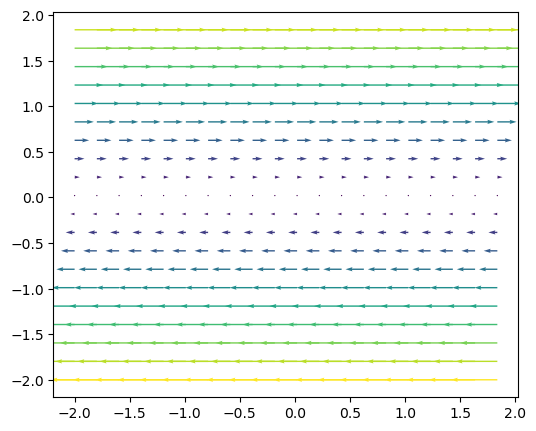

In [12]:
%reset -f
import numpy as np
import matplotlib.pyplot as plt

gammax = 1
t = np.linspace(0, 1, 100)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
u = np.zeros((len(t), len(x), len(y)))
v = np.zeros((len(t), len(x), len(y)))

for jx in range (len(x)):
    for jt in range (len(t)):
        u[jt, :, jx] = gammax * y

    v = np.zeros((len(t), len(x), len(y)))

wspd = np.sqrt(u ** 2 + v ** 2)
t_index = 0

declutter = 5
plt.figure(figsize=(6, 5))
plt.quiver(x[::declutter], y[::declutter], 
               u[t_index, ::declutter, ::declutter] , 
               v[t_index, ::declutter, ::declutter] , 
               wspd[t_index, ::declutter, ::declutter], scale = 20, cmap = "viridis", )
plt.show()


Ce champ a, par définition, un tourbillon égal à $-\gamma$. Ce tourbillon signale à la fois un effet de rotation (on visualise bien qu'un disque solide qui serait placé dans le champ se mettrait à tourner dans le sens inverse des aiguilles d'une montre) et un effet de déformation qui cisaille le fluide en l'étirant vers la droite en haut et vers la gauche en bas.




Considérons maintenant le champ 


$$ 
u(x,y) = -\Omega  y \qquad
v(x,y) = \Omega x
$$

dont les solutions sont des trajectoires tournant à vitesse angulaire $\Omega$ autour de l'origine.

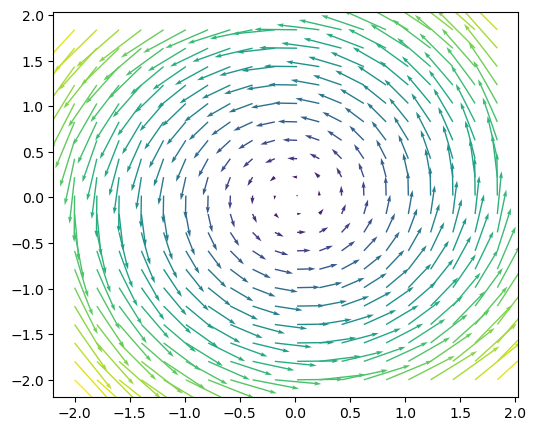

In [13]:
%reset -f 
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 100)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)

u = np.zeros((len(t), len(x), len(y)))
v = np.zeros((len(t), len(x), len(y)))
Omega = 1
for jx in range (len(x)):
    for jy in range(len(y)):
        for jt in range (len(t)):
            u[jt, jy, jx] = -Omega * y[jy]
            v[jt, jy, jx ] = Omega * x[jx]

wspd = np.sqrt(u ** 2 + v ** 2)
t_index = 0

declutter = 5
plt.figure(figsize=(6, 5))
plt.quiver(x[::declutter], y[::declutter], 
               u[t_index, ::declutter, ::declutter] , 
               v[t_index, ::declutter, ::declutter] , 
               wspd[t_index, ::declutter, ::declutter], scale = 20, cmap = "viridis", )
plt.show()

Le tourbillon de ce second champ est $2\Omega$ (et non $\Omega$!), soit deux fois la vitesse angulaire des trajectoires. Ceci montre bien que le tourbillon **ne traduit pas** la rotation locale uniquement, car elle en vaut en fait le double! La différence (tourbillon moins rotation locale) correspond aux cisaillements simples en $x$ et en $y$.

Question bonus: existe-t-il du cisaillement *pur* dans ce fluide? Du cisaillement *simple*?


*Réponse*: il n'y a pas de cisaillement pur, mais bien du cisaillement simple (en $x$ et en $y$) dont l'effet combiné s'annule ($\partial v/\partial x + \partial u / \partial y = 0$).




## 6.3 - Loi de composition des mouvements

Les mouvements et dynamiques des particules atmosphériques sont repérés, sur Terre, depuis des instruments qui sont solidaires de sa surface. Or les lois de la dynamique de Newton, qui dictent la façon dont une masse est accélérée en présence de forces (et donc la façon dont sa vitesse et sa position changent au cours du temps), s'appliquent dans un repère dit "inertiel", c'est-à-dire absolument fixe. Il est cependant bien connu que la Terre est sphérique (son rayon moyen est de $a=6371$ km), et qu'elle tourne sur elle-même (une révolution de 360° = 2 $\pi$ rad s'effectue en 23 h 56 min 4s).

Nous devons à présent comprendre les implications de la rotondité et de la rotation de la Terre sur les équations qui régissent l'évolution des particules atmosphériques.

Lors du cours, nous démontrons que nous pouvons appliquer la loi de Newton "Forces appliquées sur la particule" = "masse de la particule" multipliée par "accélaration de la particule mesurée dans un repère attaché à la surface de la Terre", au prix de l'ajout de deux forces fictives (donc d'origine non-physique) qui prennent en compte le caractère non-inertiel du repère utilisé: une force dite "centrifuge", et une force dite "de Coriolis".

La stratégie pour cette démonstration suit un raisonnement en quatre temps.

1. On définit un problème dans une géométrie plus simple que celle de la Terre.
2. On s'intéresse au mouvement d'un objet initialement au repos et qui n'est plus soumis à aucune force; on voit alors apparaître l'existence d'une force centrifuge.
3. On s'intéresse au mouvement d'un objet avec une vitesse initiale tangentielle, puis avec une vitesse initiale radiale; on voit alors apparaître l'existence d'une force de Coriolis
4. On adapte ce problème au cas de la rotation de la Terre


Au terme des points 1. - 3., nous montrons que si une particule de masse $m$ est animée d'une vitesse initiale $(U, V)$ selon les directions tangentielle ($\vec{T}$) et radiale ($\vec{N}$ orienté vers l'intérieur du mouvement) dans un repère tournant à vitesse angulaire $\Omega$ et dont l'origine décrit un cercle de rayon $R$, elle subira l'effet de deux forces fictives qu'il est nécessaire d'ajouter au bilan des forces:

$$
\sum \vec{F}_\textrm{réelles} - m\Omega^2 R \vec{N} - 2 m \Omega U\vec{N} + 2m\Omega V \vec{T} = m\vec{a}
$$
où $\vec{a}$ est l'accélération mesurée dans le repère tournant.

L'annexe 6.A2 permet de visualiser les accélérations perçues dans ce repère en jouant sur les valeurs de $U$ et $V$. 

* En prescrivant $U=V=0$, la particule est simplement "éjectée" dans la direction radiale (avant d'acquérir une vitesse tangentielle du fait de sa vitesse relative acquise): la particule semble alors ressentir une force qui lui fait fuir le centre ("centrifuge") proportionnelle à $\Omega^2 R$  et qui l'éloigne de l'origine dans la direction radiale.

* En prescrivant $V=0$ mais $U>0$, on ajoute à la vitesse d'entraînement une composante de vitesse dans la direction tangentielle. La particule est accélérée vers la droite, et cette accélération s'ajoute au mouvement centrifuge décrit ci-dessus.

* En prescrivant $V < 0$ mais $U = 0$, le mouvement centrifuge demeure mais la particule est également accélérée dans la direction opposée à $\vec{T}$, donc sur la droite de la vitesse initiale qui était radiale.

* Enfin, en prescrivant $U$ de façon à ce qu'elle annule la vitesse d'entraînement ($U=-\Omega R$), la particule est immobile vue depuis le sol, mais est accélérée vers l'intérieur ($\vec{N}$) vue depuis le repère tournant.


Que retenir de tout cela? Dans un repère en rotation, un mouvement inertiel (donc en ligne droite et à vitesse constante tel que mesurés depuis un repère absolu) présente une trajectoire ni rectiligne, ni à vitesse constante. **Il est nécessaire d'ajouter à l'accélération de la particule deux types de corrections**.



A terme du point 4., on déduit que dans un repère $(\vec{i}, \vec{j}, \vec{k})$ attaché à la surface de la Terre et décrivant les directions "est", "nord", et "haut", respectivement, l'accélération mesurée dans ce repère peut être égalée à la somme des forces à condition d'ajouter une forces fictive:

$$
\vec{F_{Co}} = - m f \vec{k} \times\vec{u} \qquad \text{Force de Coriolis}
$$

avec $f:=2\Omega\sin\phi$ le "paramètre de Coriolis" ($\phi$ désignant la latitude), et $\Omega\approx 7.27\times10^{-5}$ rad/s.

La force centrifuge est en pratique équilibrée par le fait que la forme de la Terre n'est pas parfaitement sphérique, ce qui contribute à créer une composante non radiale à la force de réaction du sol sur la particule et à exactement équilibrer cette force centrifuge. Cette force sera donc omise dans les prochains développements.




## 6.4 - Forme générale des équations d'évolution - notion d'advection

Considérons cette photographie spectaculaire, prise en Israël, et représentant le phénomène de **brouillard d'advection** (vu au Chapitre 4):




<img src="brouillard_advection.jpg" alt= “” width="50%" height="50%">

Source: https://fr.wikipedia.org/wiki/Advection  (consultée la dernière fois le 19 février 2026)


On comprend aisément la situation: une masse d'air relativement chaud et humide est transportée au-dessus d'un sol plus élevé et relativement froid; au contact de celui-ci, la température des parcelles chute sous la température du point de rosée $T_d$, ce qui déclenche la condensation. (A noter que dans cet exemple, l'air subit également un refroidissement adiabatique par ascendance orographique, qui peut expliquer la formation du brouillard).


Considérons la situation depuis une parcelle d'air provenant de la plaine. Cette parcelle possède un certain nombre d'attributs physiques qui la rendent unique parmi toutes les autres: sa position ($x(t), y(t), z(t)$), son état thermodynamique ($T(t), p(t), \rho(t), q(t)$), et sa vitesse ($u(t), v(t), w(t)$). C'est le changement au cours du temps de ces attributs, exprimé mathématiquement par la dérivée temporelle, qui va dicter l'évolution de l'état de la parcelle - par exemple, la fraction d'eau sous forme de vapeur ou de liquide.


Par ailleurs, un observateur fixe situé à flanc de montagne et s'intéressant à la situation, décrirait l'état thermodynamique et dynamique de l'atmosphère au moyen de *champs* dépendant des coordonnées $x$, $y$ et $z$, mais aussi du temps $t$ puisqu'en toute généralité, ces champs sont non-stationnaires. A titre d'exemple, concentrons-nous sur l'évolution de l'attribut "température" pour cet observateur fixe, $ T = T(t, x, y, z)$ (le raisonnement tient pour tout autre champ scalaire).



Supposons maintenant que l'observateur s'intéresse au cas très particulier des variations de température pour la parcelle évoquée plus haut, dont la trajectoire est connue $(x(t), y(t), z(t))$ et paramétrée par le temps. Le champ de température, maintenant restreint à une trajectoire paramétrée par le temps, devient lui aussi paramétré par le temps - à la fois de façon explicite et de façon implicite _via_ les coordonnées:

$$
T = T(t, x(t), y(t), z(t))
$$

Cette fonction décrit l'évolution de la température au sein de la parcelle.

Les coordonnées spatiales indépendantes ont disparu puisqu'on suppose qu'elles sont dépendantes du temps via la trajectoire choisie.

Dès lors, pour cet observateur, la dérivée temporelle de la température au sein de la parcelle est, par règle de dérivée en chaîne d'une fonction à plusieurs variables,

$$ \frac{\textrm{d}T}{\textrm{d}t} = \frac{\partial T}{\partial t} + \frac{\textrm{d}x}{\textrm{d}t} \frac{\partial T}{\partial x} + \frac{\textrm{d}y}{\textrm{d}t} \frac{\partial T}{\partial y} + \frac{\textrm{d}z}{\textrm{d}t} \frac{\partial T}{\partial z} $$

On identifie aisément les trois composantes de la vitesse, ce qui permet de réécrire 

$$ \frac{\partial T}{\partial t}  = - \vec{u} \cdot \nabla T  + \frac{\textrm{d}T}{\textrm{d}t} $$


Il convient de bien distinguer la signification des trois termes impliqués, dont les unités sont identiques (K/s):

- $\frac{\partial T}{\partial t}$ représente la dérivée partielle de $T$ par rapport au temps, est calculée en prenant $x$, $y$ et $z$ constants. Elle représente la variation instantanée de la température, au point $x,y,z$ et est aisément déterminée depuis un instrument fixe. Cette dérivée est parfois qualifiée d'"Eulérienne" (Section 6.1.4) car correspondant à des prises de mesures fixes par rapport au sol. On l'appelle également *dérivée locale* ou **tendance**.
- $\frac{\textrm{d}T}{\textrm{d}t}$ représente la vitesse de variation de $T$ de notre parcelle au cours de ses déplacements. Cette dérivée correspond donc à une approche *lagrangienne*. On l'appelle également dérivée *matérielle*, dérivée d'*évolution* ou dérivée *individuelle*.
- $- \vec{u} \cdot \nabla T$ est le terme dit **d'advection**. Ce terme fait le lien entre les changements de propriétés observés depuis un endroit fixe et les changements des mêmes propriétés observés depuis une parcelle évoluant avec le champ de vent.





Examinons quelques cas particuliers:

- si la dérivée d'évolution est nulle $\left(\frac{\textrm{d}T}{\textrm{d}t}=0\right)$, alors par définition la propriété en question est constante au sein de la parcelle; on dit que cette propriété est *conservée*. Dans ce cas, la tendance locale de température est uniquement dictée par l'advection.
- si le champ de vent est nul (atmosphère statique), alors l'advection est nulle évolution locale et évolution de la propriété de la parcelle se confondent
- si le champ de vent est perpendiculaire au gradient de température, alors l'advection est également nulle et évolution locale et évolution de la propriété de la parcelle se confondent


Reprenons le champ initial introduit en début de chapitre pour comprendre où se trouvent les zones d'advection positive, négative, et nulle.


In [2]:
# On charge le fichier netcdf
%reset -f
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import requests

# Charger le fichier netcdf
try: # On essaie localement. Si le fichier n'est pas là, on le télécharge 
  ds = xr.open_dataset("./data/91e319d26f6f4705ff1f278b3925c0b6.nc")
except FileNotFoundError:
  # Télécharger le fichier
  url = "https://raw.githubusercontent.com/fmassonn/teaching/master/LPHY1365/data/91e319d26f6f4705ff1f278b3925c0b6.nc"

  r = requests.get(url)
  with open("91e319d26f6f4705ff1f278b3925c0b6.nc", "wb") as f:
    f.write(r.content)
  ds = xr.open_dataset("./91e319d26f6f4705ff1f278b3925c0b6.nc")


# On affiche les variables présentes dans le fichier
print(ds)



# On charge les données sur un sous-domaine d'étude


lon_min, lon_max = -15, -5
lat_min, lat_max = 35, 45

time_selection = '2024-09-17T12:00:00'

# Sélectionner les données de vent à 10 mètres d'altitude pour le temps spécifié
# Sélectionner les données sur la région d'intérêt 
# ERA5 donne les latitudes décroissantes, donc on doit faire attention à l'ordre des latitudes dans la sélection
u10 = ds['u10'].sel(time=time_selection, longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))
v10 = ds['v10'].sel(time=time_selection, longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))
t2m = ds['t2m'].sel(time=time_selection, longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))
lon = ds['longitude'].sel(longitude=slice(lon_min, lon_max))
lat = ds['latitude'].sel(latitude=slice(lat_max, lat_min))  


<xarray.Dataset>
Dimensions:    (time: 24, longitude: 121, latitude: 161)
Coordinates:
  * time       (time) datetime64[ns] 2024-09-17 ... 2024-09-17T23:00:00
  * longitude  (longitude) float32 -30.0 -29.75 -29.5 -29.25 ... -0.5 -0.25 0.0
  * latitude   (latitude) float32 60.0 59.75 59.5 59.25 ... 20.5 20.25 20.0
Data variables:
    u10        (time, latitude, longitude) float32 ...
    v10        (time, latitude, longitude) float32 ...
    t2m        (time, latitude, longitude) float32 ...
Attributes:
    CDI:          Climate Data Interface version 2.5.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 19 21:40:40 2026: cdo sellonlatbox,330,360,20,60 91...
    CDO:          Climate Data Operators version 2.5.1 (https://mpimet.mpg.de...


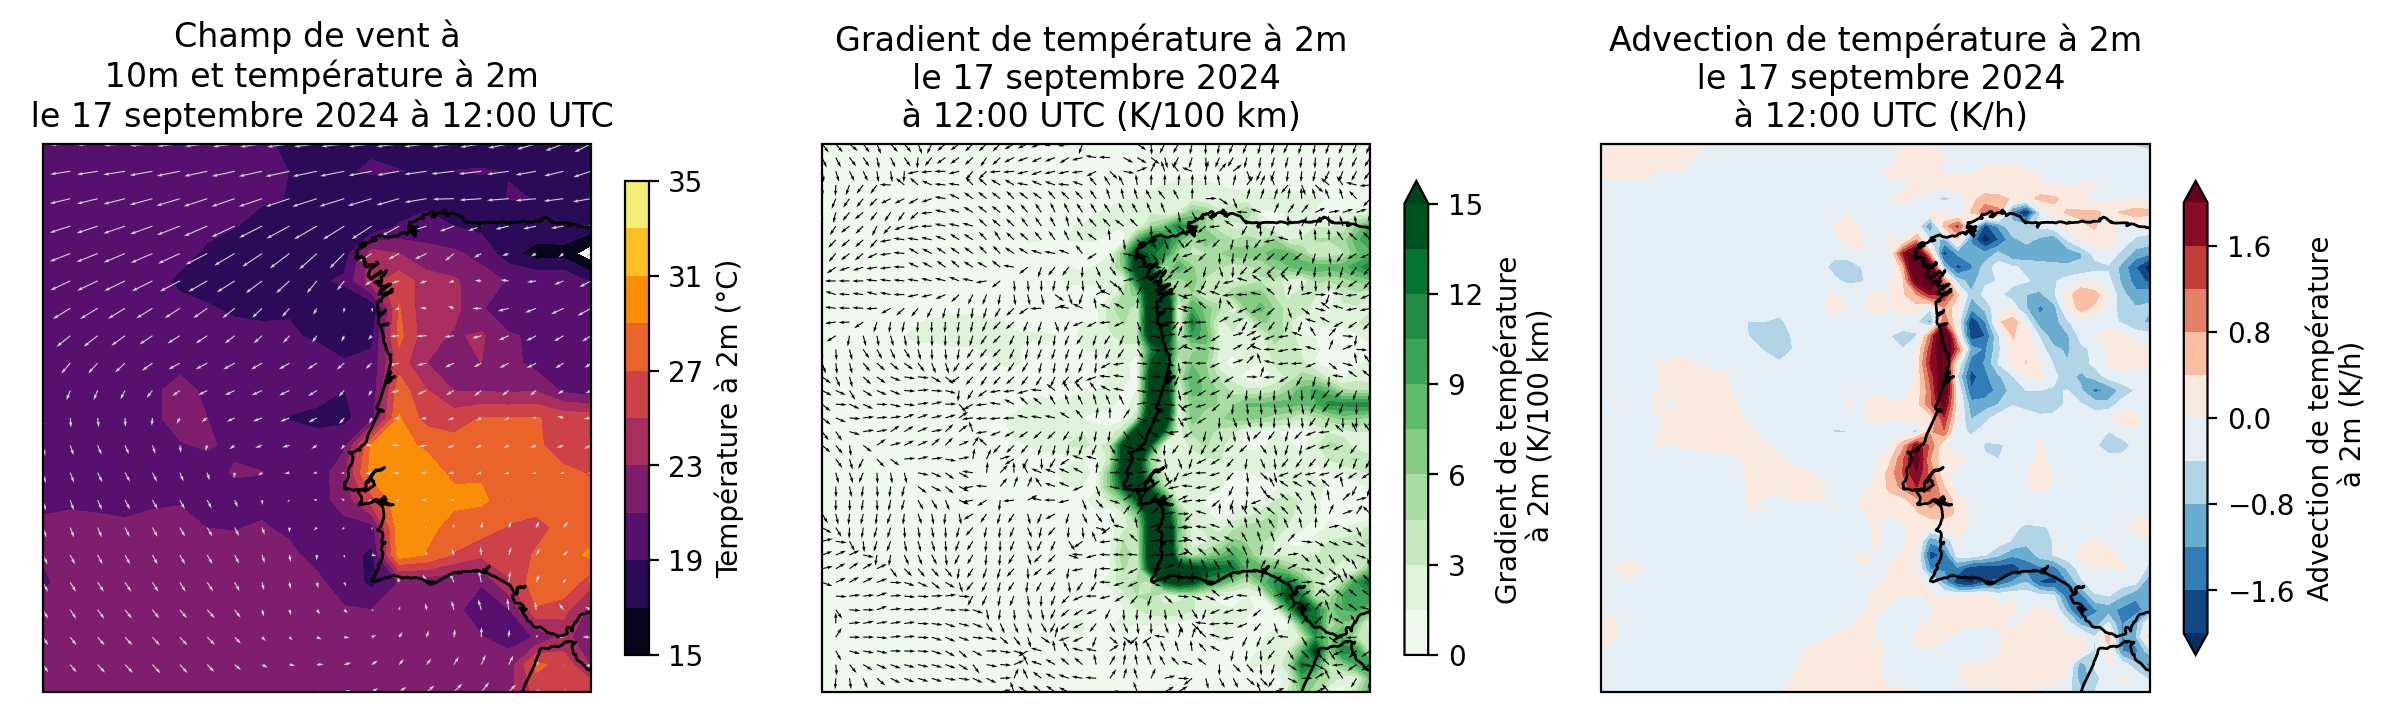

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# On crée une figure avec trois subplots: les champs, le gradient de température, et l'advection. 

fig, ax = plt.subplots(1, 3,figsize=(12, 24), subplot_kw={'projection': ccrs.PlateCarree()}, dpi = 200)

ax[0].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax[0].add_feature(cfeature.COASTLINE)

declutter = 2  
# Tracer le champ de T2m en contourf, avec un pas de 1°C entre 25 et 35°C, et une palette de couleurs allant du bleu au rouge (par exemple, 'coolwarm').
levels = np.arange(15, 36, 2)
cf = ax[0].contourf(lon[::declutter], lat[::declutter], t2m.values[::declutter, ::declutter] - 273.15, levels=levels, cmap='inferno')

plt.colorbar(cf, ax= ax[0],  label='Température à 2m (°C)', shrink = 0.1)

# On limite la color bar à 25-35°C pour mieux visualiser les variations de température dans cette plage, et on ajoute une légende pour indiquer que les flèches représentent le vent à 10 mètres d'altitude.
cf.set_clim(levels[0], levels[-1])

# Tracer les flèches de vent à 10 mètres d'altitude
 
ax[0].quiver(lon[::declutter], lat[::declutter], u10.values[::declutter, ::declutter], v10.values[::declutter, ::declutter], scale=300, color='lightgray', width=0.002, headwidth=3, headlength=5, headaxislength=4.5)

ax[0].set_title('Champ de vent à\n 10m et température à 2m\n le 17 septembre 2024 à 12:00 UTC')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')



# Figure centrale: gradient de température
# On calcule d'abord ce gradient.
dTdphi, dTdlam = np.gradient(t2m.values - 273.15, (lat.values[1] - lat.values[0]) / 360 * 2 * np.pi, 
                             (lon.values[1] - lon.values[0]) / 360 * 2 * np.pi)  # gradient en degrés de longitude et de latitude. 
# Les latitudes sont fournies dans l'ordre décroissant, mais on prend en compte le signe 
# en utilisant bien le pas de latitude négatif.


# On teste np gradient car pas sûr de comprendre ce que fait l'opération.
# On prend un array 2d 4 par 4 et on calcule son gradient
#test_array = np.array([[1, 2, 3, 4], [2.5, 3.5, 4.5, 5.5], [3.5, 4, 5, 6], [4, 5, 6, 7]])
#dtest_dlam, dtest_dphi = np.gradient(test_array, 1, 1)
#print("Test array:")
#print(test_array)
#print("Gradient along lambda:")
#print(dtest_dlam)
#print("Gradient along phi:")
#print(dtest_dphi)


# On convertit ces dérivées pour arriver à des gradients métriques. 
# Comme dTdlam est un tableau 2D et que lat un tableau 1D, on doit faire du broadcasting pour faire la division.
dTdx = dTdlam / (6371000 * np.repeat(np.cos(np.radians(lat.values)), len(lon)).reshape(len(lat), len(lon)))  # conversion du gradient en degrés de longitude à un gradient en mètres
dTdy = dTdphi / 6371000  # conversion du gradient en degrés de latitude à un gradient en mètres


# !!! à noter que pour bien faire, on devrait calculer le gradient en coordonnées sphériques, mais pour simplifier, on suppose que les coordonnées sont cartésiennes (ce qui est une approximation raisonnable pour une petite région comme celle-ci)


# On calcule la norme du gradient pour pouvoir normaliser les flèches de gradient et les rendre plus visibles sur le graphe.
grad_norm = np.sqrt(dTdx**2 + dTdy**2)
dTdx_normalized = dTdx / grad_norm
dTdy_normalized = dTdy / grad_norm

# On représent le gradient avec quiver
ax[1].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax[1].add_feature(cfeature.COASTLINE)

levels = np.linspace(0, 15.0, 11 )
cf = ax[1].contourf(lon, lat, grad_norm * 100000, levels=levels, cmap='Greens', extend = 'max')

# Adjust the colorbar in size to match the subplot
plt.colorbar(cf, ax= ax[1],  label='Gradient de température\n à 2m (K/100 km)', shrink = 0.1)
cf.set_clim(levels[0], levels[-1])

ax[1].quiver(lon, lat, dTdx_normalized, dTdy_normalized, scale=50, color='black', width=0.002, headwidth=3, headlength=5, headaxislength=4.5)


ax[1].set_title('Gradient de température à 2m \nle 17 septembre 2024\n à 12:00 UTC (K/100 km)')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')    



# Enfin on calcule le terme d'advection de la température à 2 mètres d'altitude, qui est défini par - (u * dTdx + v * dTdy).

advection = - (u10.values * dTdx + v10.values * dTdy)
levels = np.linspace(-2.0, 2.0, 11)
ax[2].set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax[2].add_feature(cfeature.COASTLINE)
cf = ax[2].contourf(lon, lat, advection * 3600, levels=levels, cmap='RdBu_r', extend = 'both')
ax[2].set_title('Advection de température à 2m\n le 17 septembre 2024\n à 12:00 UTC (K/h)')
ax[2].set_xlabel('Longitude')
ax[2].set_ylabel('Latitude')    

plt.colorbar(cf, ax= ax[2],  label='Advection de température\n à 2m (K/h)', shrink = 0.1)

fig.tight_layout()
plt.show()



Que voyons-nous? 

- Près de Madrid, le champ de vent souffle dans la même direction que le gradient, ce qui cause une advection négative: des masses d'air plus froides sont en effet transportées ("advectées") vers des zones où l'air était initialement plus chaud.
- Le long de la côte sud, le gradient de température pointe vers le nord (car contraste mer-terre) mais le vent est du sud; le transport contribute à faire baisser les températures localement
- Le long de la façade ouest (Lisbonne, Porto), le vent d'est fait augmenter les températures de plusieurs °C / h car il est à contre-gradient du champ de température.


# 6.5 - Le coin des curieux(ses)
## 6.5.1 -Décomposition matricielle du gradient de vitesse

C'est bien la manière dont le champ de vitesse varie dans l'espace qui définit le type de mouvements rencontrés en dynamique des fluides. Mathématiquement, ces variations s'étudient au moyen du **gradient du champ de vitesse**.

Soit un champ de vitesse bidimensionnel $\mathbf{U}(x,y) = (u(x,y), v(x,y))$.

Outre la translation (mouvement plan élémentaire), les différents types de mouvements locaux peuvent être obtenus en décomposant le gradient de vitesse, qui traduit donc la variation spatiale de $\mathbf{U}$.

Le gradient de vitesse est la matrice :

$$
\nabla \mathbf{U}
=
\begin{pmatrix}
\partial u / \partial x & \partial u / \partial y \\
\partial v / \partial x & \partial v / \partial y
\end{pmatrix}
$$

Comme $\nabla \mathbf{U}$ est une matrice $2 \times 2$, on peut la décomposer algébriquement en une partie symétrique et une partie antisymétrique :

$$
\nabla \mathbf{U} = \mathbf{S} + \mathbf{A}
$$

avec

$$
\mathbf{S} =
\frac{1}{2}
\left(
\nabla \mathbf{U}
+
(\nabla \mathbf{U})^T
\right)
$$

et

$$
\mathbf{A} =
\frac{1}{2}
\left(
\nabla \mathbf{U}
-
(\nabla \mathbf{U})^T
\right)
$$

On vérifie trivialement que :

$$
\mathbf{S} + \mathbf{A} = \nabla \mathbf{U}
$$

---

### Partie symétrique du gradient de vitesse : la déformation

La matrice symétrique $\mathbf{S}$ s'écrit :

$$
\mathbf{S}
=
\begin{pmatrix}
\partial u / \partial x &
\frac{1}{2}
\left(
\partial u / \partial y + \partial v / \partial x
\right)
\\
\frac{1}{2}
\left(
\partial u / \partial y + \partial v / \partial x
\right)
&
\partial v / \partial y
\end{pmatrix}
$$

Elle décrit la **déformation locale**, et est composée de deux contributions :

- la **divergence** (les termes diagonaux) :

$$
\nabla \cdot \mathbf{U}
=
\frac{\partial u}{\partial x}
+
\frac{\partial v}{\partial y}
$$

qui correspond à une dilatation ou compression locale causant une variation d'aire ;

- le **cisaillement pur** (les termes hors diagonale), qui correspond à une déformation sans rotation.

---

### Partie antisymétrique : rotation solide

La matrice antisymétrique $\mathbf{A}$ s'écrit :

$$
\mathbf{A}
=
\begin{pmatrix}
0 &
\frac{1}{2}
\left(
\partial u / \partial y - \partial v / \partial x
\right)
\\
\frac{1}{2}
\left(
\partial v / \partial x - \partial u / \partial y
\right)
&
0
\end{pmatrix}
$$

Elle décrit la **rotation solide locale** du fluide.

---

### Résumé

Le mouvement local d'un fluide peut être décomposé en :

$$
\text{Mouvement}
=
\underbrace{\text{Déformation}}_{\text{divergence + cisaillement pur}}
+
\text{Rotation solide}
$$

---

### Remarque importante : cisaillement simple *vs.* cisaillement pur

Un **cisaillement simple** :

$$
u = \gamma y, \qquad v = 0
$$

donne :

$$
\nabla \mathbf{U}
=
\begin{pmatrix}
0 & \gamma \\
0 & 0
\end{pmatrix}
$$

qui se décompose donc en

$$
\mathbf{A}
=
\begin{pmatrix}
0 & \gamma/2 \\
\gamma/2 & 0
\end{pmatrix}
\qquad
\mathbf{B}
=
\begin{pmatrix}
0 & \gamma/2 \\
-\gamma/2 & 0
\end{pmatrix}
$$

Donc le cisaillement simple contient donc :

- du cisaillement pur
- et de la rotation solide

---

En revanche, un **cisaillement pur** :

$$
u = \frac{\gamma}{2} y,
\qquad
v = \frac{\gamma}{2} x
$$

donne :

$$
\mathbf{A}
=
\begin{pmatrix}
0 & \gamma/2 \\
\gamma/2 & 0
\end{pmatrix}
\qquad
\mathbf{B} = 0
$$

et n'est donc associé à aucune rotation solide.

---

### Remarque : déformation sans divergence ni cisaillement

Un champ :

$$
u = \gamma x,
\qquad
v = -\gamma y
$$

donne :

$$
\nabla \mathbf{U}
=
\begin{pmatrix}
\gamma & 0 \\
0 & -\gamma
\end{pmatrix}
$$

Ce mouvement correspond à une **déformation pure sans divergence** et **sans rotation**.


![image](./deformation/Diapositive2.png)

## 6.5.2 - Visualisation des accélérations fictives

Dans le script ci-dessous, on peut jouer avec les valeurs de $U$, $V$ pour comprendre l'effet de la rotation.

In [36]:

# Le but de ce script est de développer une intuition graphique
# pour l'accélération de Coriolis et centripète. Nous allons commencer
# par tracer un repère de référence avec des vecteurs appelés I et J (selon x et y)
# que nous allons animer d'une rotation à une vitesse de Omega.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from ipywidgets import interact
import ipywidgets as widgets

# Définir les paramètres de la rotation
Omega = 2.0 * np.pi / 15  # Vitesse de rotation (rad/s)

R = 6.0  # Rayon de la rotation

# Définir les vecteurs de référence I et J
# Ces vecteurs sont indépendants du temps et donc de la rotation

I = np.array([1, 0])  # Vecteur I (x)
J = np.array([0, 1])  # Vecteur J (y)


# On définit un axe "temps" en secondes de 0 à 15 secondes, avec un pas de 0.01 seconde pour une animation fluide.
time = np.arange(0,15/4, 0.01)

# On suppose  une particule de vitesse initiale (U, V) dans le repère tournant, c'est à dire de vitesse (V, U + Omega * R) dans le repère fixe, et on trace sa trajectoire.
# On suppose que la particule n'est soumise à aucune force et donc se déplace en ligne droite à vitesse constante dans le repère fixe.

U = - Omega * R #2* 1.0  # Vitesse initiale de la particule dans le repère tournant  
V = 0 * 1.0  # Vitesse initiale de la particule dans le repère tournant  

# On va créer une fonction update() qui sera appelée à chaque étape de l'animation pour mettre à jour les positions des vecteurs I et J en fonction du temps.


def update(jt):

        fig, ax = plt.subplots (1, 2, figsize = (10, 6),  dpi = 150)

        
        # On crée une figure représentant les vecteurs de base I et J, absolument fixes.
        ax[0].arrow(0, 0, I[0], I[1], head_width=0.1, head_length=0.1, fc='blue', ec='blue', label='I')
        # On ajoute le nom du vecteur à côté de la tête de la flèche
        ax[0].text(I[0] + 0.1, I[1] + 0.1, r'$\vec{I}$', color='blue', fontsize=12)
        ax[0].arrow(0, 0, J[0], J[1], head_width=0.1, head_length=0.1, fc='blue', ec='blue', label='J')
        # On ajoute le nom du vecteur à côté de la tête de la flèche
        ax[0].text(J[0] + 0.1, J[1] + 0.1, r'$\vec{J}$', color='blue', fontsize=12)
        # On nomme et on écrit ce point O à côté de l'origine
        ax[0].scatter(0, 0, 10, color='blue', marker='o', label='Origine du repère fixe')
        ax[0].text(-0.2, -0.2, r'$O_a$', color='blue', fontsize=12)

        # On définit l' origine d'un repère tournant, dont les coordonnées sont R cos(Omega * t) et R sin(Omega * t


        origin_rotating = np.array([R * np.cos(Omega * time), R * np.sin(Omega * time)])

       
        # On fixe le temps en fonction de l'argument jt qui a été passé dans la fonction
        t = time[jt]

        ax[0].scatter(origin_rotating[0, jt], origin_rotating[1, jt], 10, color='red', marker='o', label='Origine du repère tournant')
        # On nomme et on écrit ce point O_r à côté de l'origine
        ax[0].text(origin_rotating[0, jt] - 0.2, origin_rotating[1, jt] - 0.2, r'$O_r$', color='red', fontsize=12)


        # On trace la trajectoire déjà parcourue par l'origine du repère tournant depuis t = 0 jusqu'à t = time[jt]
        ax[0].plot(origin_rotating[0,0:jt], origin_rotating[1,0:jt], 'k:', label='Trajectoire du repère tournant')



        # On trace les vecteurs de base radial et tangentiel du repère tournant

        # Ces vecteurs sont des combinaisons linéaires de I et J:
        N = - np.array([np.cos(Omega * t), np.sin(Omega * t)])  # Vecteur radial, pointant vers l'intérieur par convention,
        T = np.array([-np.sin(Omega * t), np.cos(Omega * t)]) # Vecteur tangentiel, pointant dans le sens de la rotation par convention


        ax[0].arrow(origin_rotating[0, jt], origin_rotating[1, jt], N[0], N[1], head_width=0.1, head_length=0.1, fc='red', ec='red', label='N')
        ax[0].arrow(origin_rotating[0, jt], origin_rotating[1, jt], T[0], T[1], head_width=0.1, head_length=0.1, fc='red', ec='red', label='T')
        # On ajoute les noms des vecteurs à côté de la tête de la flèche
        ax[0].text(origin_rotating[0, jt] + N[0] + 0.1, origin_rotating[1, jt] + N[1] + 0.1, r'$\vec{N}$', color='red', fontsize=12)
        ax[0].text(origin_rotating[0, jt] + T[0] + 0.1, origin_rotating[1, jt] + T[1] + 0.1, r'$\vec{T}$', color='red', fontsize=12)

    
        
        v0 = np.array([U + Omega * R, V])  # Vitesse initiale de la particule

        # La variable particle_position donne les coordonnées dans le repère fixe de la trajectoire de la particule.

        particle_position = np.full((2, len(time)), np.nan)  # Initialiser les positions de la particule

        particle_position[0, :] = R - v0[1] * time 
        particle_position[1, :] = v0[0] * time  


        # On trace la trajectoire de la particule dans le repère fixe

        ax[0].plot(particle_position[0,0:jt], particle_position[1,0:jt], 'g--', label='Trajectoire de la particule', zorder = 1000)
        
        # On marque la particule avec un carré
        ax[0].scatter(particle_position[0, jt], particle_position[1, jt], 10, color='green', marker='s', label='Particule', zorder = 1000  )  



        # Deuxième étape: on va maintenant représenter la trajectoire de la particule perçue depuis le repère tournant.
        
        # On se met dans le subplot de droite la même situation mais vue du repère tournant.

        # Le vecteur position de la particule dans le repère fixe est connue (ci-dessus)

        # On remplit un disque de rayon R * 1.1 pour mieux visualiser la rotation. Ce disque est centré sur l'origine et est rempli par une couleur rouge pâle; on trace des rayons très légers à intervalles de 5° pour mieux visualiser la rotation.
        # les rayons tournent évidemment avec le mouvement.

        circle = plt.Circle((0, 0), R * 1.1, color=[1.0, 0.8, 0.8] , zorder = -500)
        ax[0].add_artist(circle)
        for angle in np.arange(0, 360, 20):
            ax[0].plot([0, R * 1.1 * np.cos(np.radians(angle + Omega * time[jt] * 180 / np.pi))], [0, R * 1.1 * np.sin(np.radians(angle + Omega * time[jt] * 180 / np.pi))], color=[1.0, 0.5, 0.5], zorder = -400)


        # On trace un fond bleu pâle pour mieux visualiser la rotation. Ce fond est centré sur l'origine et a une largeur de 2R et une hauteur de 2R.
        ax[0].add_patch(plt.Rectangle((-10 * R, -10 * R), 20 * R, 20 * R, color='lightblue', alpha=1, zorder = -1000))
        # On dessine des lignes verticales et horizontales pour mieux visualiser la rotation. Ces lignes sont espacées de 1 unité et ne tournent pas avec le mouvement.
        for x in np.arange(-10 * R, 10 * R, 1):
            ax[0].plot([x, x], [-10 * R, 10 * R], color=[0.5, 0.5, 1.0], zorder = -800)
        for y in np.arange(-10 * R, 10 * R, 1):
            ax[0].plot([-10 * R, 10 * R], [y, y], color=[0.5, 0.5, 1.0], zorder = -800)


        # On trace un point en (6, 4) resté au sol, avec uns smiley
        bigDotX = 6     
        bigDotY = 4
        # On aligne et on centre le smiley sur le point
        ax[0].text(bigDotX, bigDotY, r'$\bigodot$', color='orange', fontsize=12, ha='center', va='center')

        # Le vecteur position de la particule depuis l'origine du repère tournant est donnée, dans la base fixe, par
        tmp_1 = particle_position[0, :] - origin_rotating[0, :]  # Coordonnée x de la particule dans la base fixe, multiplie I
        tmp_2 = particle_position[1, :] - origin_rotating[1, :]  # Coordonnée y de la particule dans la base fixe, multiplie J


        # On projette le vecteur tmp_1 * I + tmp_2 * J sur les vecteurs er et et pour trouver les coordonnées de la particule dans le repère tournant.
        # Comme er = I * cos(Omega * t) + J * sin(Omega * t) et et = -I * sin(Omega * t) + J * cos(Omega * t), on trouve que:
        
        particle_position_T = - tmp_1 * np.sin(Omega * time) + tmp_2 * np.cos(Omega * time)
        # et en et:
        particle_position_N = -tmp_1 * np.cos(Omega * time) - tmp_2 * np.sin(Omega * time)

        # On trace dans le second subplot les vecteurs T et N, ainsi que l'origine du repère tournant      
        ax[1].arrow(0, 0, 1, 0, head_width=0.1, head_length=0.1, fc='red', ec='red', label=r'$\vec{T}$')
        ax[1].arrow(0, 0, 0, 1, head_width=0.1, head_length=0.1, fc='red', ec='red', label=r'$\vec{N}$')
        # On ajoute le nom de l'origine du repère tournant à côté de l'origine
        ax[1].text(-0.4, -0.4, r'$O_r$', color='red', fontsize=12)
        # On ajoute le nom des vecteurs à côté de la tête de la flèche
        ax[1].text(1.1, 0.1, r'$\vec{T}$', color='red', fontsize=12)
        ax[1].text(0.1, 1.1, r'$\vec{N}$', color='red', fontsize=12)


        ax[1].scatter(0, 0, 10, color='red', marker='o', label='Origine du repère tournant')
        ax[1].set_xlim(-2.5, 5.5)
        ax[1].set_ylim(-2.5, 5.5)
        ax[1].set_aspect('equal')
        ax[1].set_axisbelow(True)
        #ax[1].grid()  

        # On trace de nouveau les rayons du disque pour mieux visualiser la rotation. Ces rayons tournent sont maintenant fixes dans le repère tournant et ne tournent plus avec le mouvement.
        circle = plt.Circle((0, +R), R * 1.1, color=[1.0, 0.8, 0.8] , zorder = -500)
        ax[1].add_artist(circle)
        for angle in np.arange(0, 360, 20):
            ax[1].plot([0, R * 1.1 * np.sin(np.radians(angle))], [R, R - 1.1 * R * np.cos(np.radians(angle))], color=[1.0, 0.5, 0.5], zorder = -400)

        # On trace le maillage du repère fixe, qui devient tournant lorsque le repère tournant est choisi comme repère de référence. Ces lignes sont espacées de 1 unité et tournent avec le mouvement.

        # On connait la relation entre x dans le repère fixe et sa coordonnée sur T et N dans le repère tournant:
        # x (dans la base T, N) = cst --> dans la base (T, N), on a -sin(Omega * t) T - cos(Omega * t) N  = cst


        # On met un fond bleu comme précédemment
        ax[1].add_patch(plt.Rectangle((-10 * R, -10 * R), 20 * R, 20 * R, color='lightblue', alpha=1, zorder = -1000))
        # Idem pour y
        for x in np.arange(-10 * R, 10 * R, 1):
            ax[1].plot(-x * np.sin(Omega * time[jt]) + np.arange(-10 * R, 10 * R, 0.1) * np.cos(Omega * time[jt]), R -x * np.cos(Omega * time[jt]) - np.arange(-10 * R, 10 * R, 0.1) * np.sin(Omega * time[jt]), color=[0.5, 0.5, 1.0], zorder = -800)
        for y in np.arange(-10 * R, 10 * R, 1):
            ax[1].plot(-np.arange(-10 * R, 10 * R, 0.1) * np.sin(Omega * time[jt]) + y * np.cos(Omega * time[jt]),R -np.arange(-10 * R, 10 * R, 0.1) * np.cos(Omega * time[jt]) - y * np.sin(Omega * time[jt]), color=[0.5, 0.5, 1.0], zorder = -800)



        # On trace la trajectoire de la particule dans le repère tournant   

        ax[1].plot(particle_position_T[0:jt], particle_position_N[0:jt ], 'g--', label='Trajectoire de la particule')
        # Marquer la particule avec un carré
        ax[1].scatter(particle_position_T[jt], particle_position_N[jt], 10, color='green', marker='s', label='Particule')   

        # On repère bigdot dans le repère tournant
        bigDotX_rot = -(bigDotX - origin_rotating[0, jt]) * np.sin(Omega * time[jt]) + (bigDotY - origin_rotating[1, jt]) * np.cos(Omega * time[jt])
        bigDotY_rot = -(bigDotX - origin_rotating[0, jt]) * np.cos(Omega * time[jt]) - (bigDotY - origin_rotating[1, jt]) * np.sin(Omega * time[jt])
        ax[1].text(bigDotX_rot, bigDotY_rot, r'$\bigodot$', color='orange', fontsize=12, ha ='center', va='center')

        # On termine par du toilettage de figure
        ax[0].set_xlim(-0.5, 10.5)
        ax[0].set_ylim(-1.5, 10.5)
        #ax[0].legend(loc='upper left', fontsize = 6)
        ax[0].set_aspect('equal')
        ax[0].set_axisbelow(True)
        #ax[0].grid()
        ax[0].set_title("Vue du repère fixe.\nVitesse de rotation $\Omega$ = " + 
                        str(Omega / (2 * np.pi) * 60) + " tours/minute\n t = " + str(np.round(time[jt], 2)) + " s")

        ax[1].set_title("Vue du repère tournant\nU = " + str(U ) + 
                        " m/s, V = " + str(V ) + " m/s\n t = " + str(np.round(time[jt], 2)) + " s")


        fig.tight_layout()


# Maintenant on crée  un slider pour faire varier le temps et observer l'animation.
interact(update, jt = (0, len(time)-1, 1))






<>:205: SyntaxWarning: invalid escape sequence '\O'
<>:205: SyntaxWarning: invalid escape sequence '\O'
/var/folders/m3/rlnbxzw916zg5rxbzlfc01h40000gq/T/ipykernel_8159/4121343702.py:205: SyntaxWarning: invalid escape sequence '\O'
  ax[0].set_title("Vue du repère fixe.\nVitesse de rotation $\Omega$ = " +


interactive(children=(IntSlider(value=187, description='jt', max=374), Output()), _dom_classes=('widget-intera…

<function __main__.update(jt)>

## 6.6 - Questions

- Soit une particule décrivant une courbe $C$ paramétrée par son abscisse curviligne $s(t)$. En introduisant les éléments cinématiques et géométriques adéquats, établir l'expression du vecteur accélération de la particule et proposer une décomposition de ce vecteur en des composantes facilement interprétables.
- Définir la notion de *rayon de courbure* au point $M$ d'une courbe $C$
- En mécanique des fluides, qu'est-ce qui distingue l'approche lagrangienne de l'approche eulérienne? 
- Quelles sont les quatre grands types de mouvements rencontrés dans un fluide géophysique? Expliciter leur effet sur le fluide à l'aide quatre schémas représentant un écoulement dans le plan
- Démontrer l'existence d'une force centrifuge et d'une force de Coriolis lorsque la trajectoire d'une particule, animée d'une vitesse initiale $(U, V)$ mesurée dans un repère en rotation à vitesse $\Omega$, est étudiée depuis ce même repère en rotation.
- Etant donné un champ de vitesse dans le plan horizontal, identifier les zones de dynamiques translationnelles, divergentes, tourbillonnaires, et de cisaillement pur.
- Etant donné un champ de vitesse dans le plan horizontal et un champ scalaire (par exemple, de température), identifier les zones d'advection positives, nulles et négatives du champ scalaire en question. Interpréter les changements physiques qui en résultent.